## Preprocessing the dataset to make it ready to use

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [48]:
df = pd.read_csv('Data/AirQualityUCI.csv', delimiter=';', decimal=',')
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [49]:
#drop the unnamed 15 and 16 col which are empty
df.dropna(axis=1, how='all', inplace=True)

In [50]:
#creation of the datetime column

df['Date_Time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S', errors='coerce')
df['Date_Time'].head()

# drop rows where Date_Time is missing
df.dropna(subset=['Date_Time'], inplace=True)
df.reset_index(drop=True, inplace=True)

# dropping the original date time cols not useful anymore
df.drop(["Date", "Time"], inplace=True, axis=1)

In [51]:
# creating a hour col 
df['Hour'] = df['Date_Time'].dt.hour
df['Day'] = df['Date_Time'].dt.day

df['weekday'] = df['Date_Time'].dt.weekday

df.head(50)

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Date_Time,Hour,Day,weekday
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00,18,10,2
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00,19,10,2
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00,20,10,2
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00,21,10,2
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00,22,10,2
5,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848,2004-03-10 23:00:00,23,10,2
6,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603,2004-03-11 00:00:00,0,11,3
7,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,60.0,0.7702,2004-03-11 01:00:00,1,11,3
8,0.9,1094.0,24.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648,2004-03-11 02:00:00,2,11,3
9,0.6,1010.0,19.0,1.7,561.0,-200.0,1705.0,-200.0,1235.0,501.0,10.3,60.2,0.7517,2004-03-11 03:00:00,3,11,3


In [52]:
#replacing -200 w nan
df.replace(-200, np.nan, inplace=True)

In [53]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Date_Time,Hour,Day,weekday
count,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,9357,9357.000000,9357.000000,9357.000000
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530,2004-09-21 16:00:00,11.498557,15.876884,3.009939
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,2004-03-10 18:00:00,0.000000,1.000000,0.000000
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800,2004-06-16 05:00:00,5.000000,8.000000,1.000000
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400,2004-09-21 16:00:00,11.000000,16.000000,3.000000
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700,2004-12-28 03:00:00,18.000000,23.000000,5.000000
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00,23.000000,31.000000,6.000000
std,1.453252,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813,NaN,6.923182,8.808653,2.000323


In [54]:
# NMHC has too many nan values so we drop the entire col
df.drop(['NMHC(GT)'], axis=1, inplace=True)
df.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Date_Time,Hour,Day,weekday
count,7674.000000,8991.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,9357,9357.000000,9357.000000,9357.000000
mean,2.152750,1099.833166,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530,2004-09-21 16:00:00,11.498557,15.876884,3.009939
min,0.100000,647.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,2004-03-10 18:00:00,0.000000,1.000000,0.000000
25%,1.100000,937.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800,2004-06-16 05:00:00,5.000000,8.000000,1.000000
50%,1.800000,1063.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400,2004-09-21 16:00:00,11.000000,16.000000,3.000000
75%,2.900000,1231.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700,2004-12-28 03:00:00,18.000000,23.000000,5.000000
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00,23.000000,31.000000,6.000000
std,1.453252,217.080037,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813,NaN,6.923182,8.808653,2.000323


In [56]:
print("Null values before ", df.isnull().sum() )

df.interpolate(method="linear", inplace=True)

print("Null values after ", df.isnull().sum() )


Null values before  CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
Date_Time           0
Hour                0
Day                 0
weekday             0
dtype: int64
Null values after  CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
Date_Time        0
Hour             0
Day              0
weekday          0
dtype: int64


### Having successfully removed all null values and removed rows with no timestamp we move to some more visualisatoin

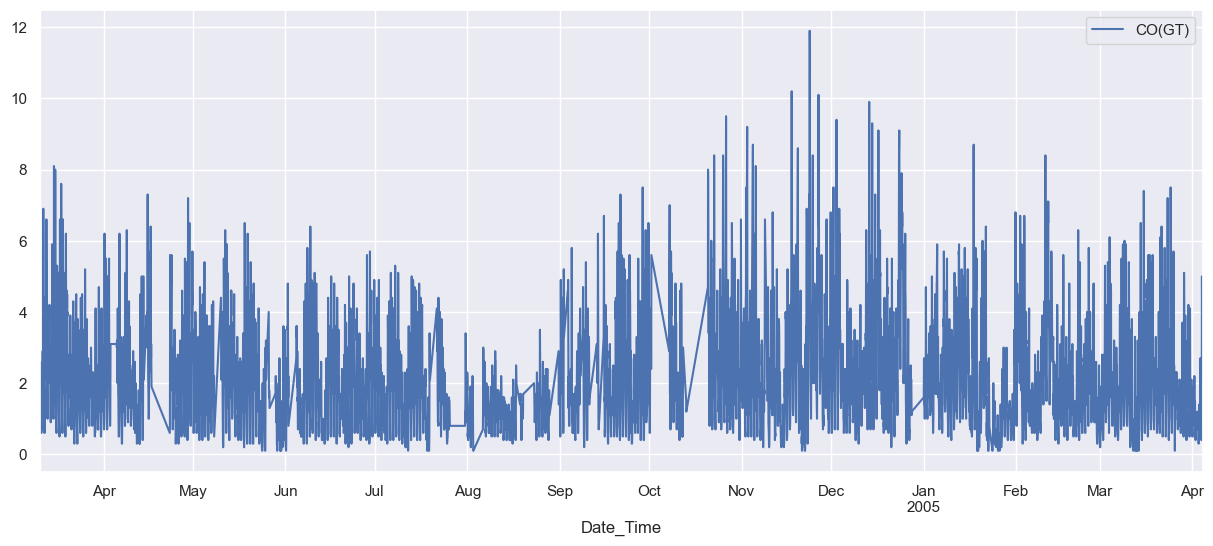

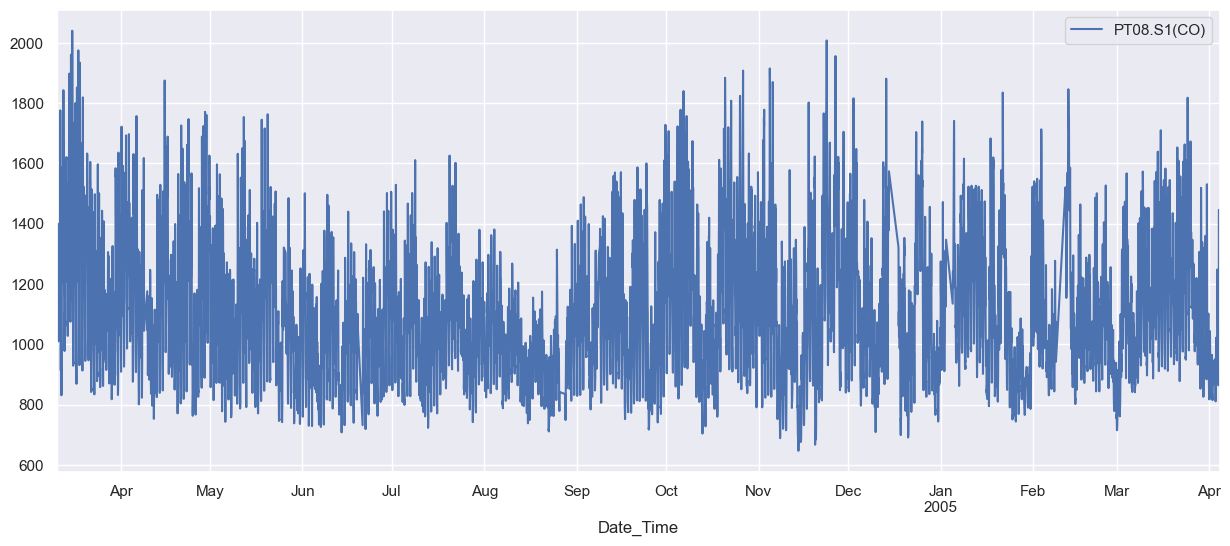

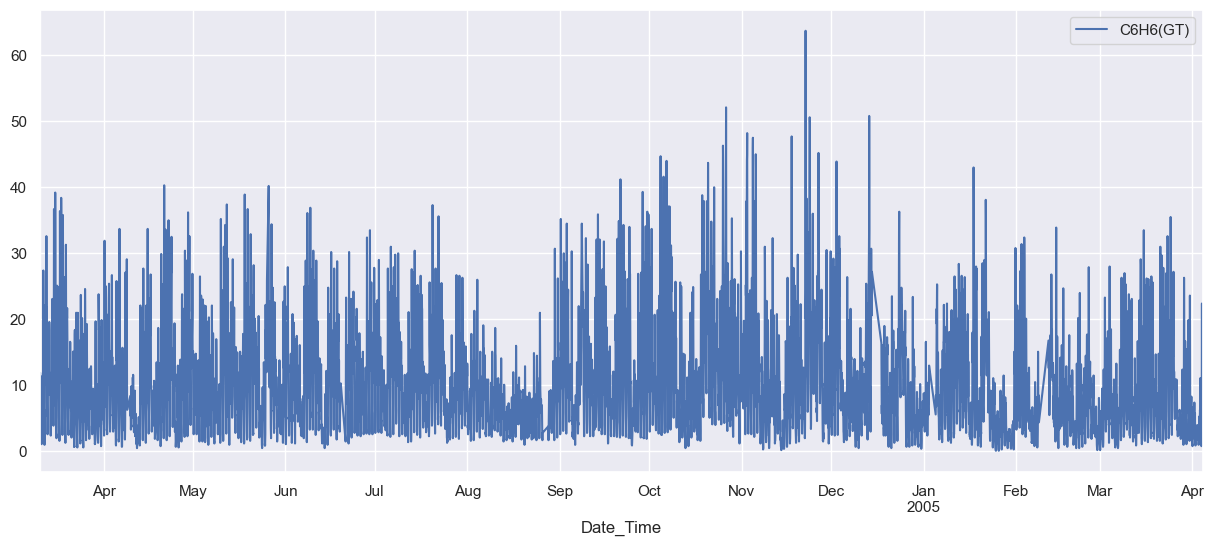

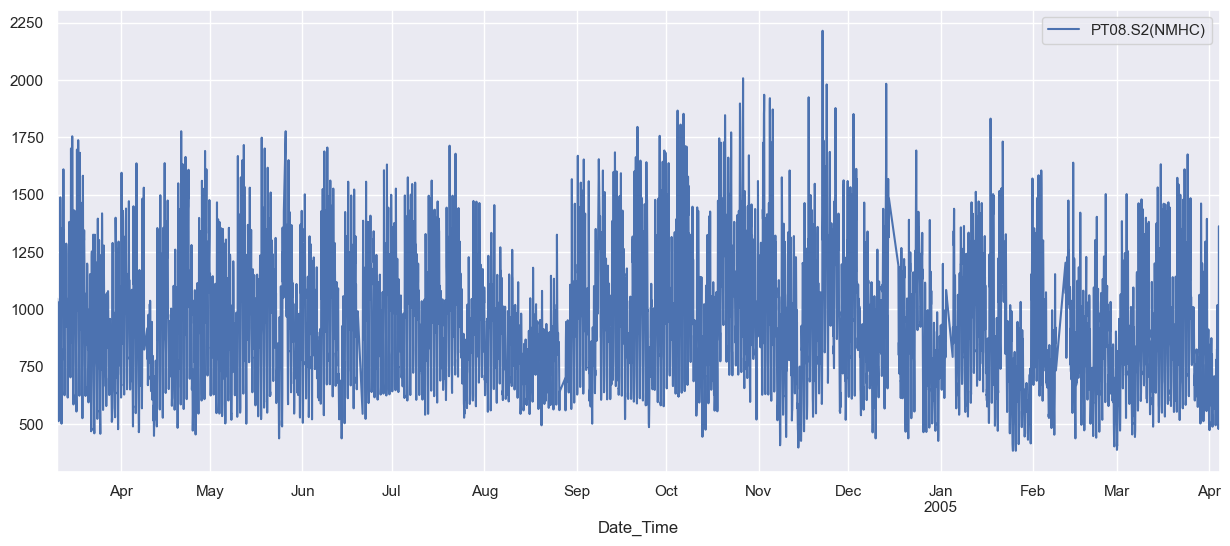

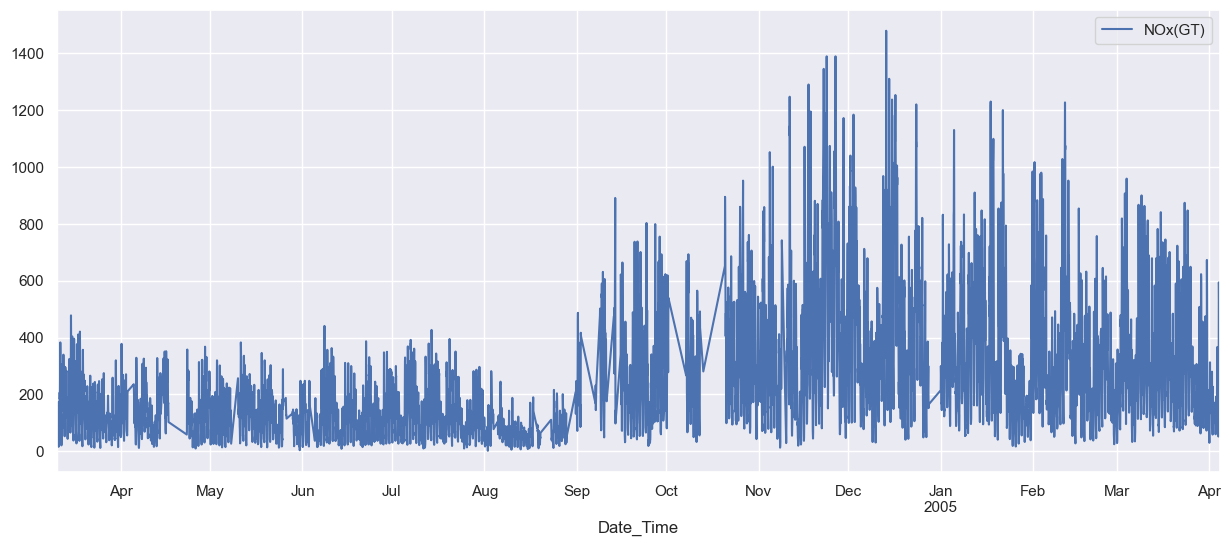

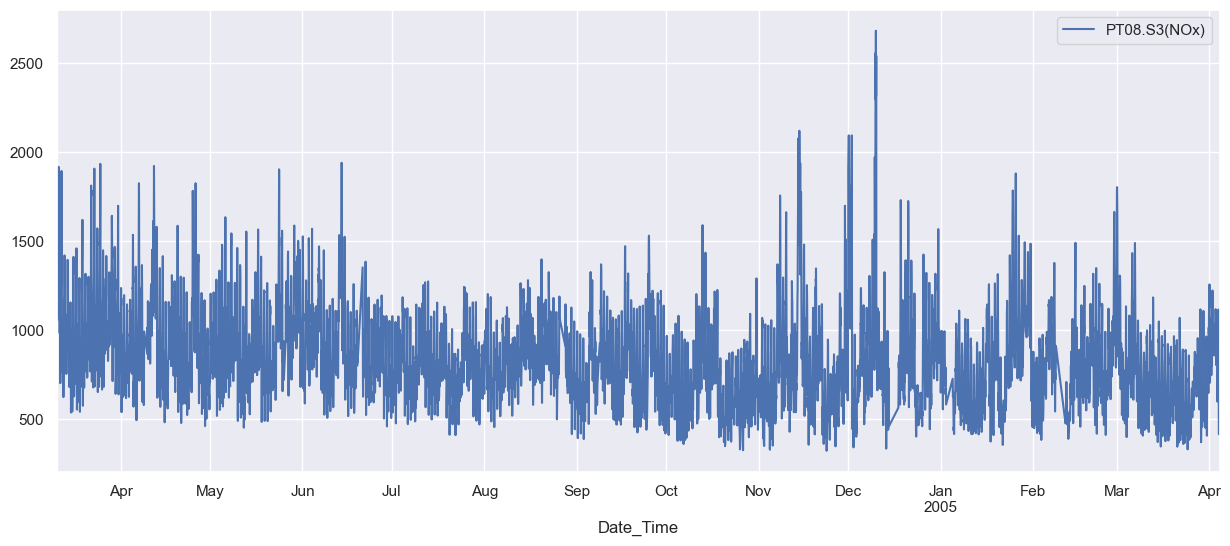

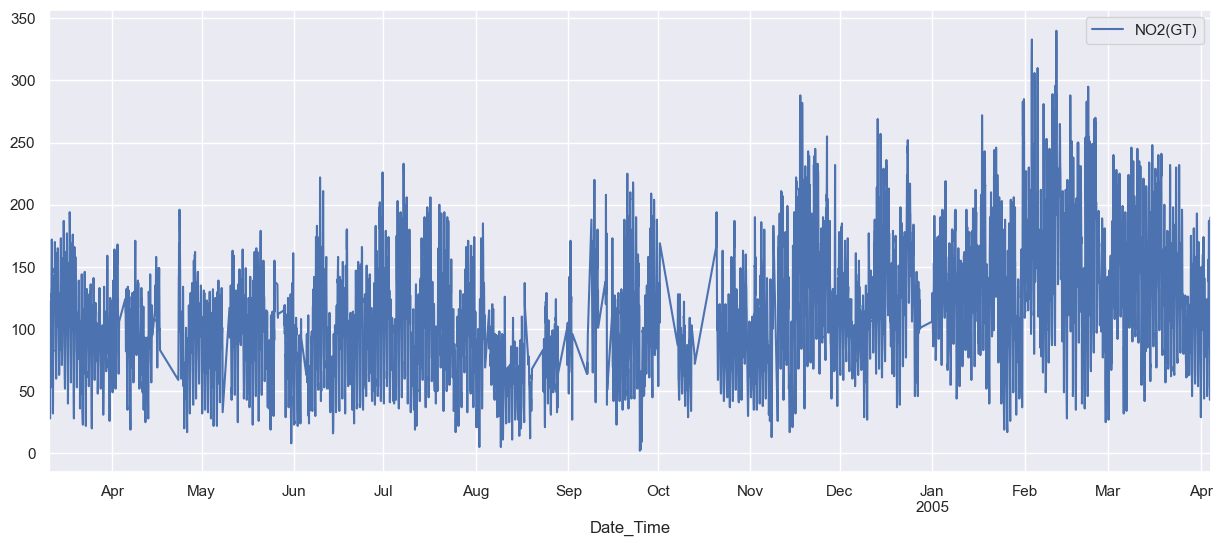

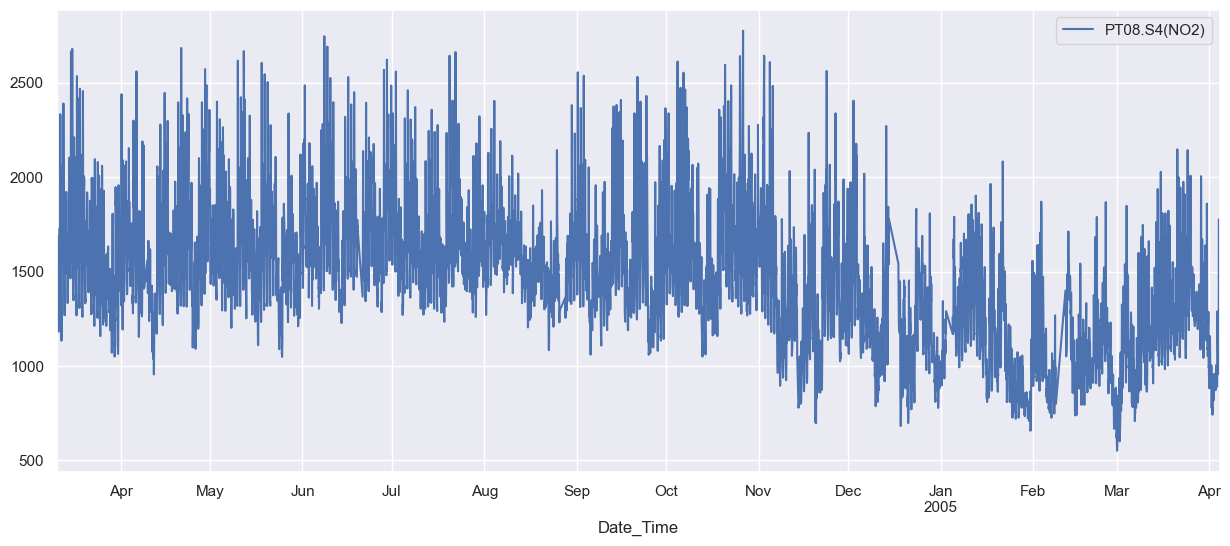

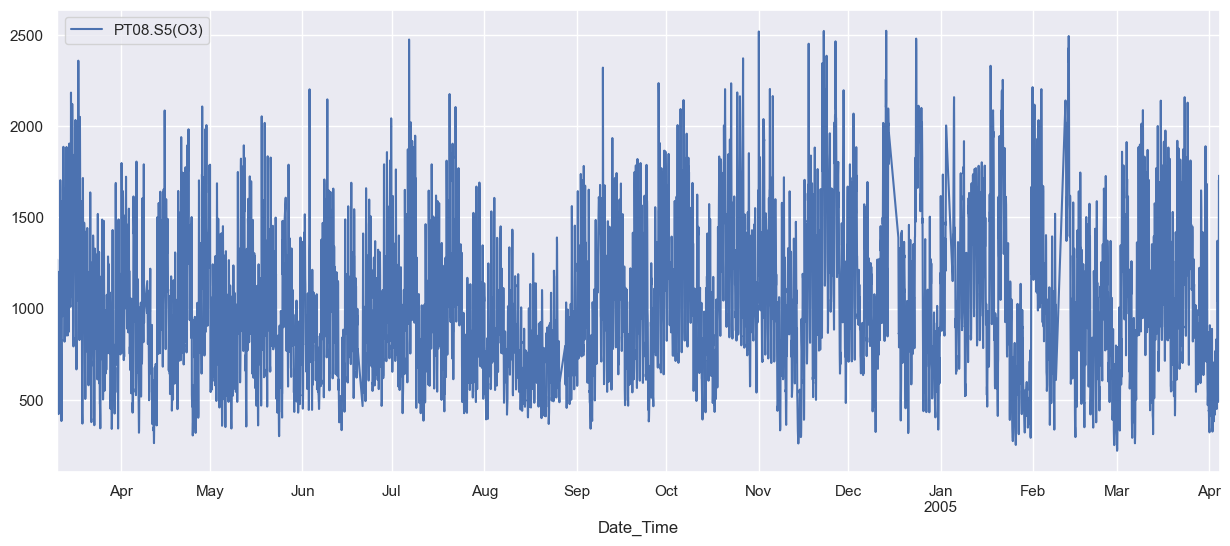

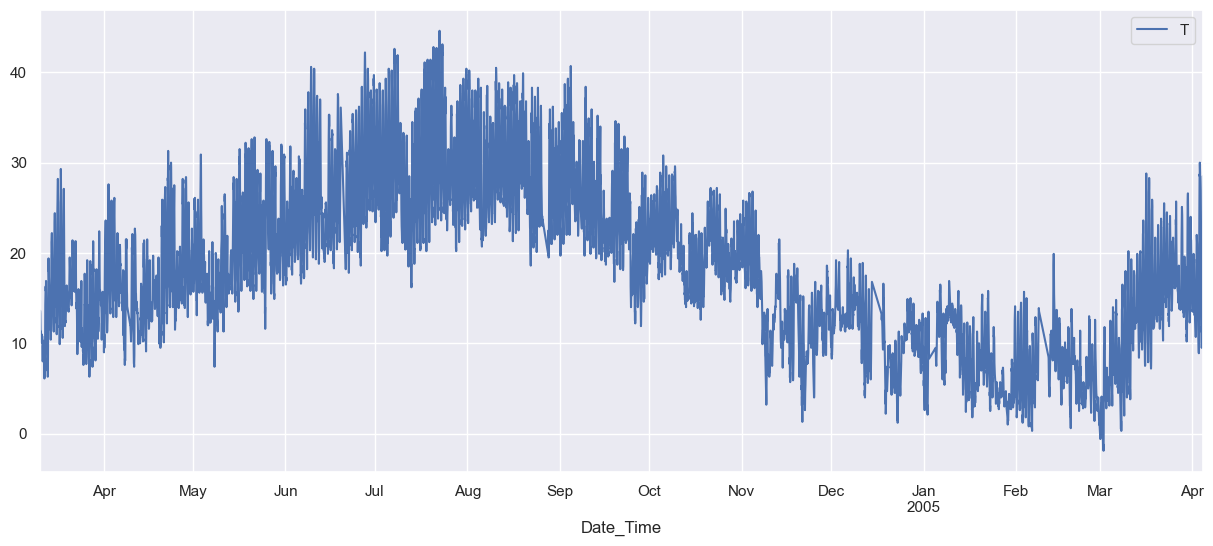

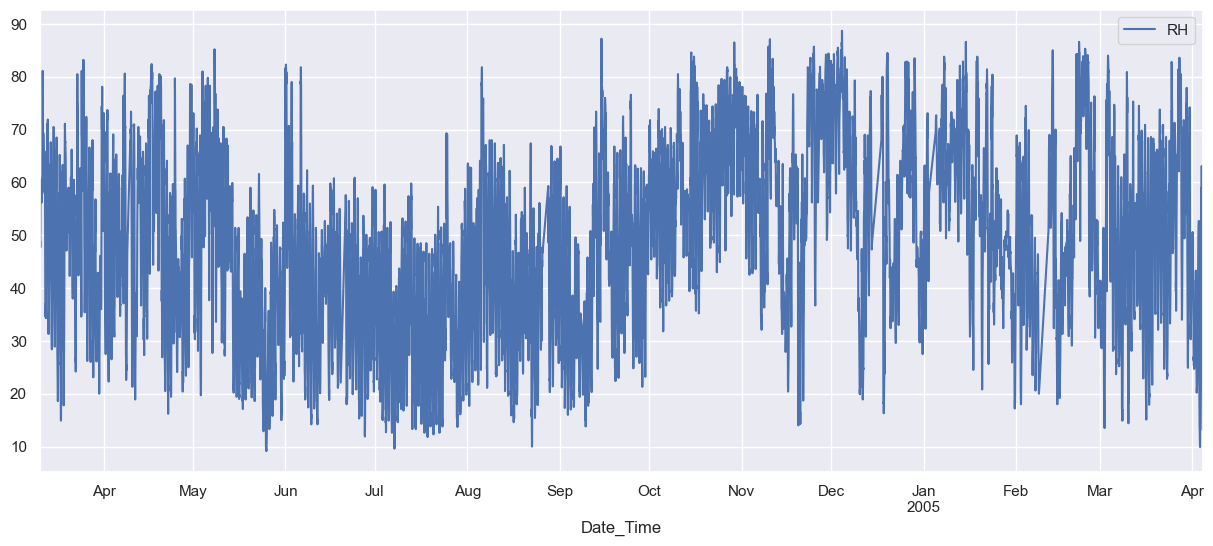

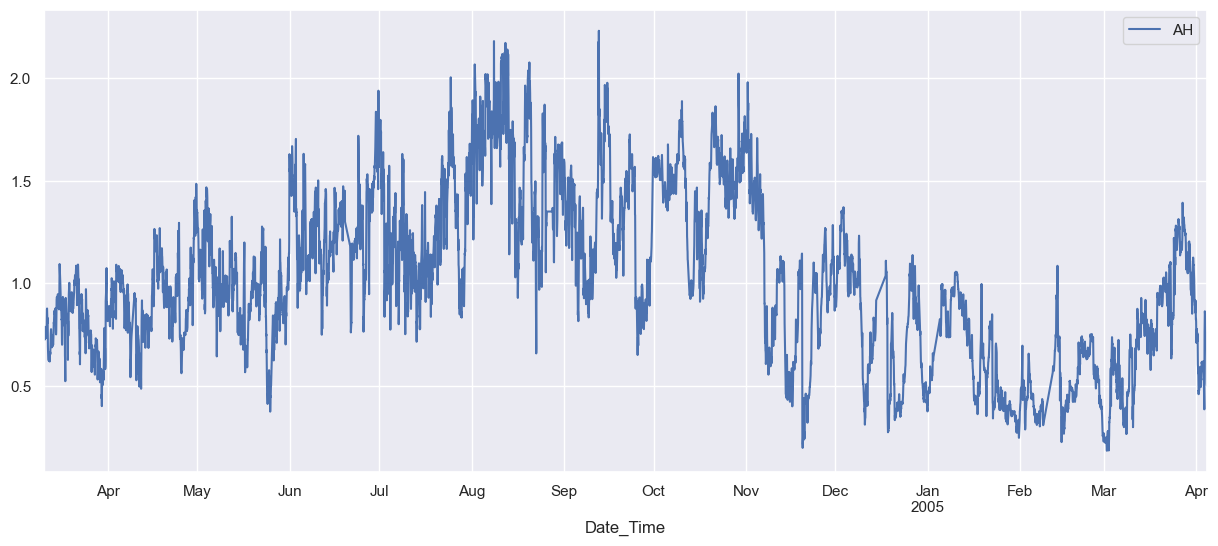

In [73]:
sns.set_theme({'figure.figsize':(15, 6)})

for feature in df:
    if feature != 'Date_Time' and feature != 'Hour' and feature != 'Day' and feature != 'weekday':
        df.plot(x='Date_Time', y=feature)
        plt.show()

## Looking at plots by week and day of week now

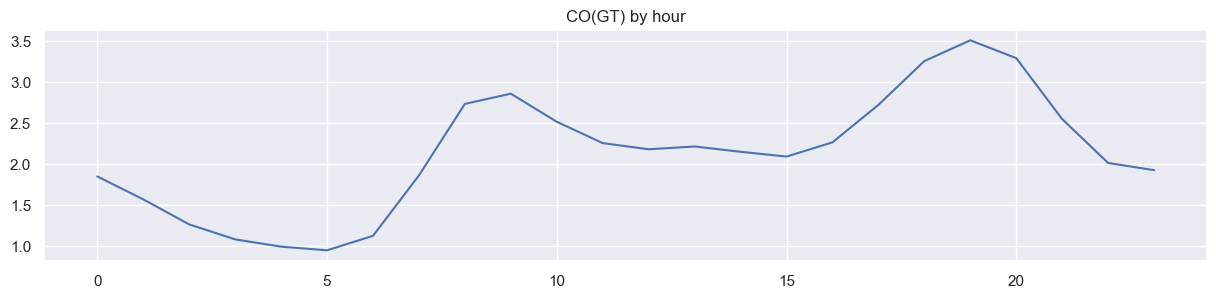

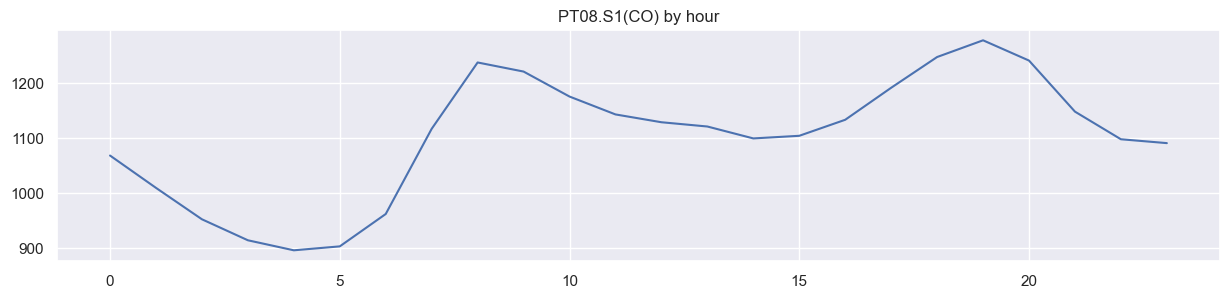

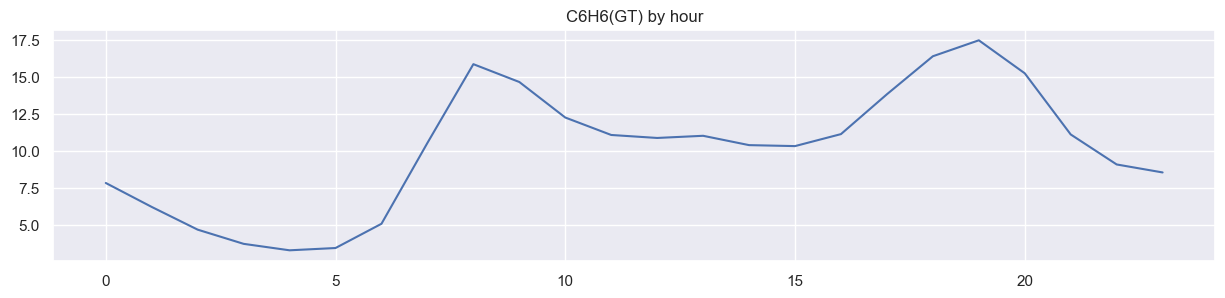

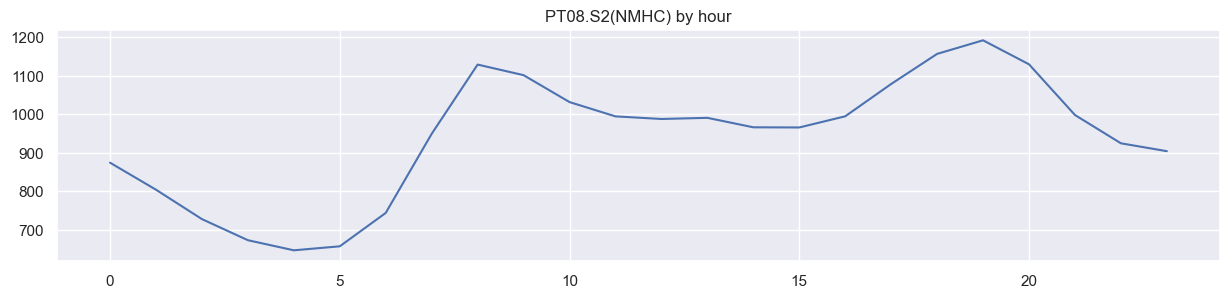

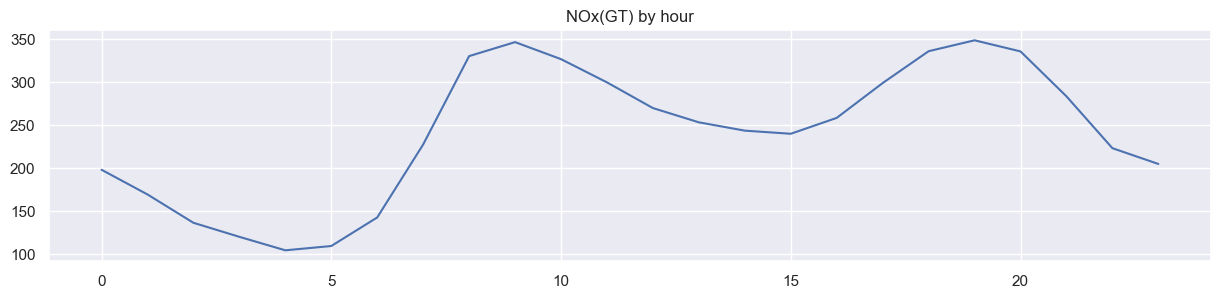

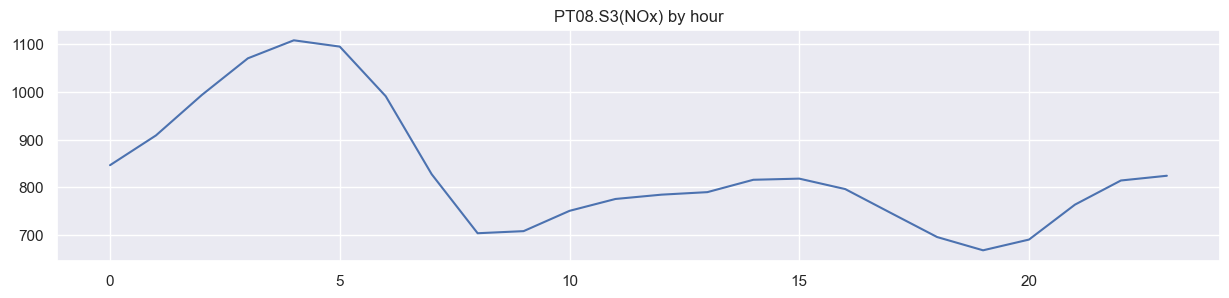

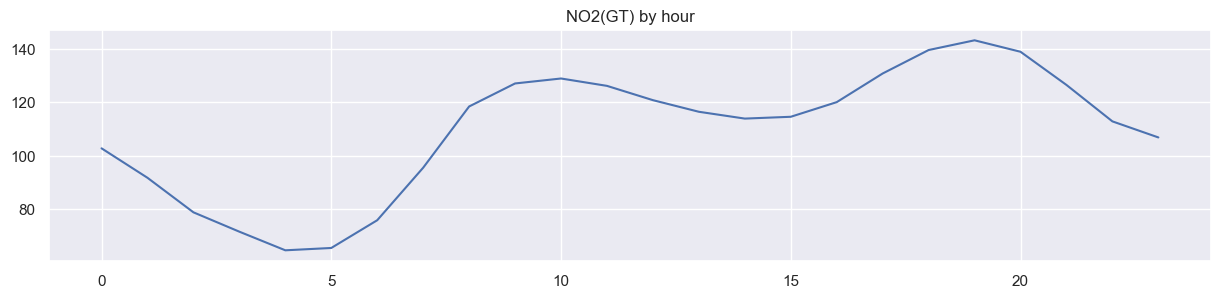

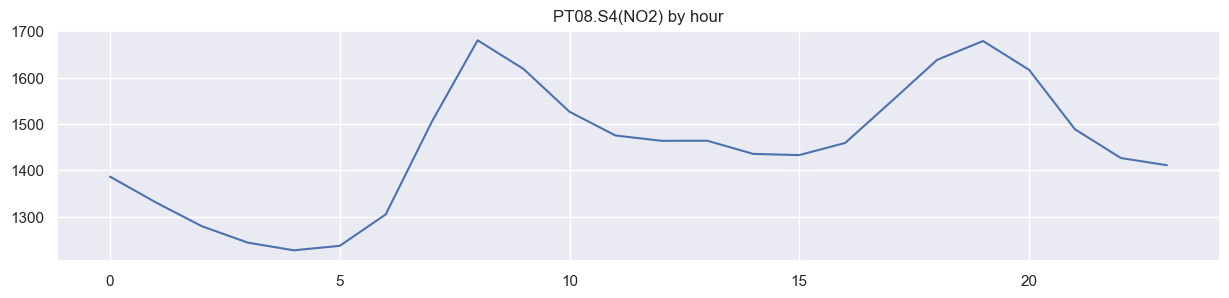

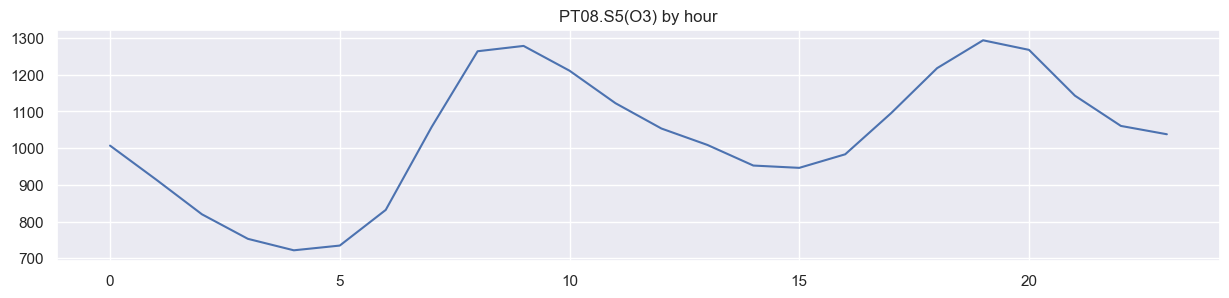

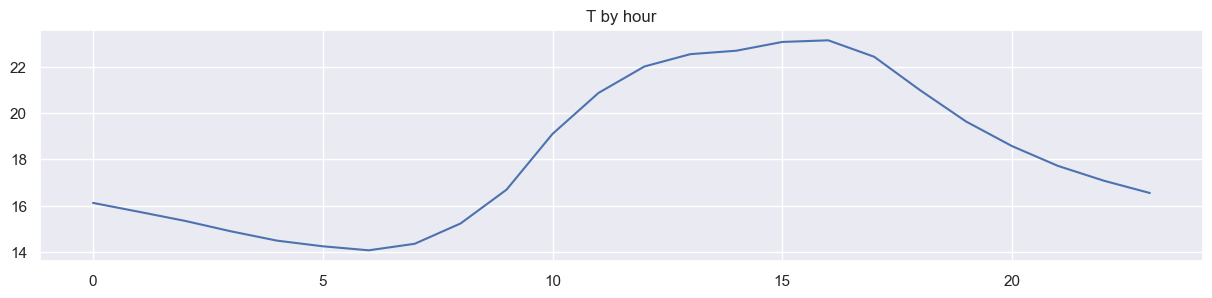

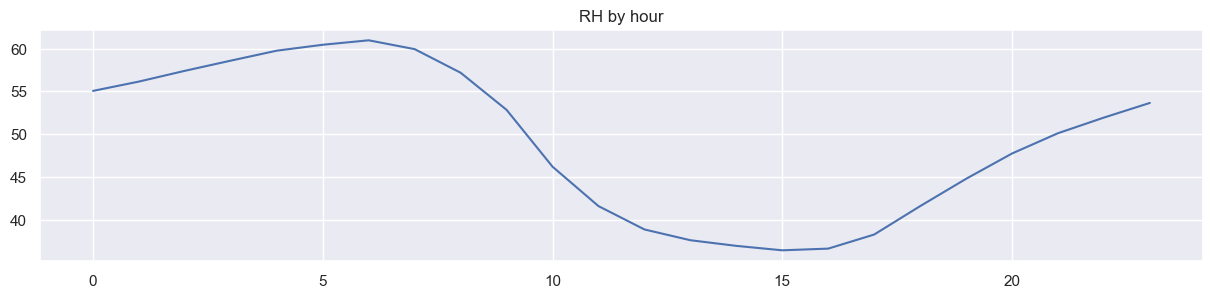

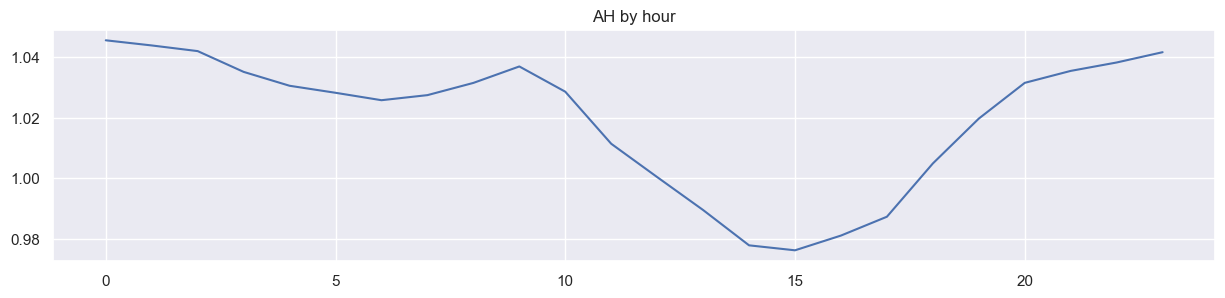

In [93]:
sns.set_theme({'figure.figsize':(15, 3)})

for feature in df:
    if feature != 'Date_Time' and feature != 'Hour' and feature != 'Day' and feature != 'weekday':
        yy = df[feature].groupby(df['Hour']).mean()
        xx = df['Hour'].groupby(df['Hour'])
        plt.plot(yy)
        plt.title(f"{feature} by hour")
        plt.show()

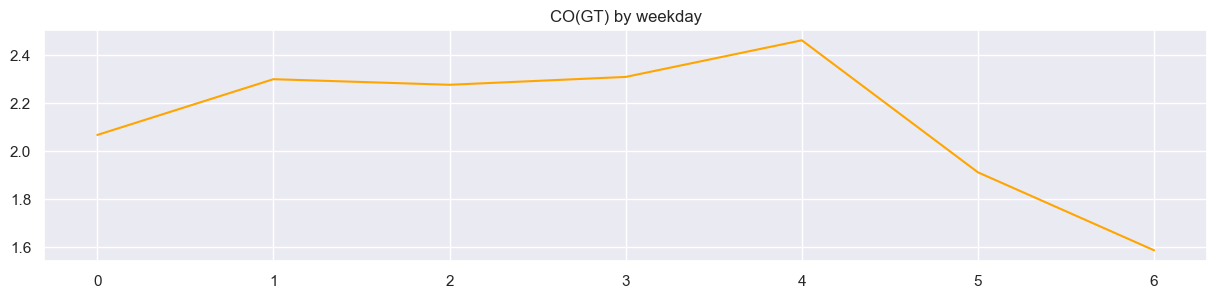

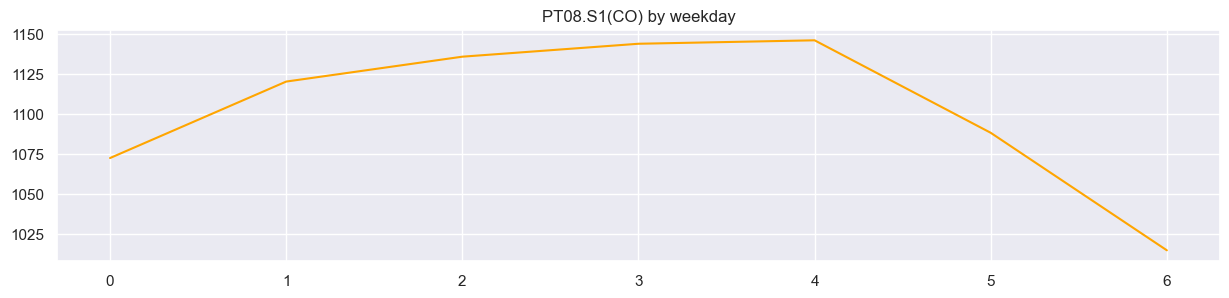

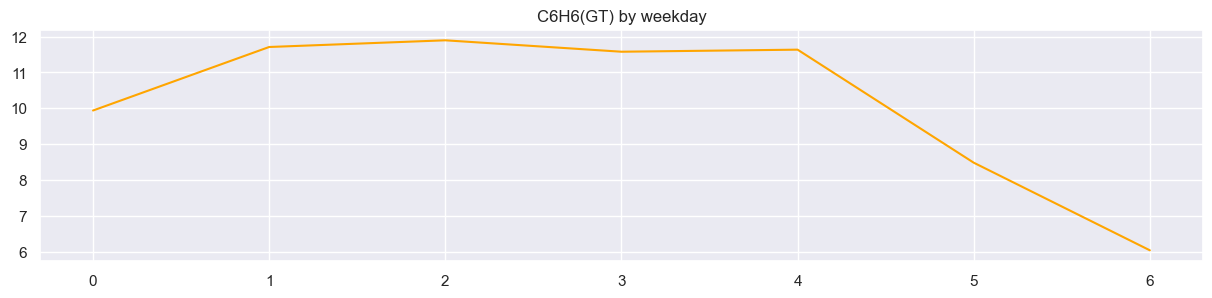

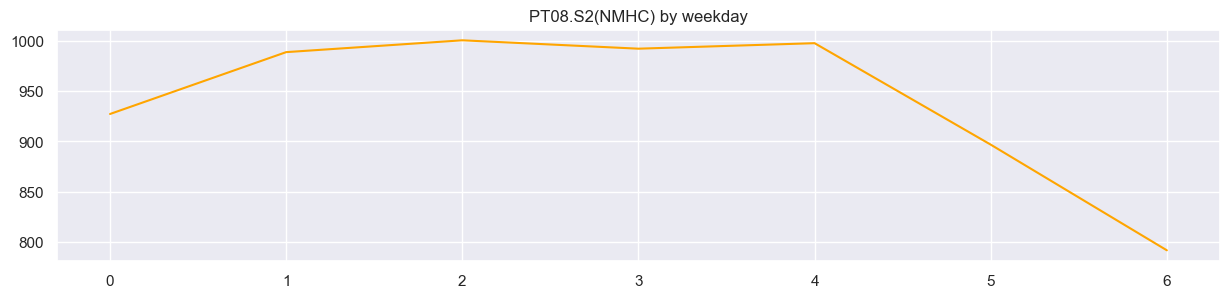

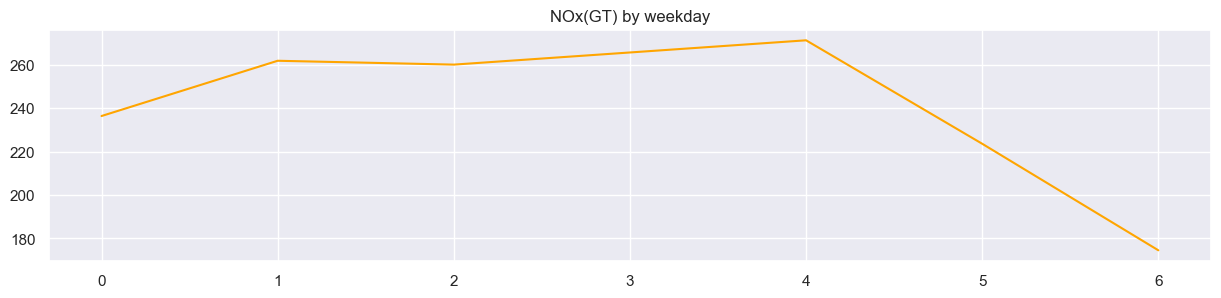

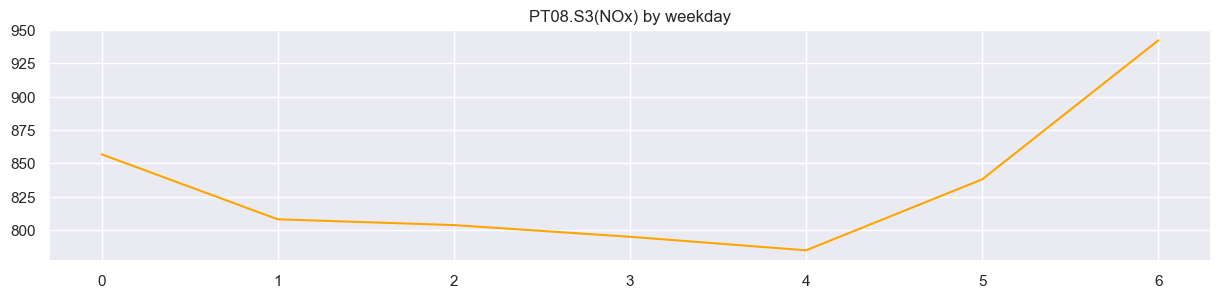

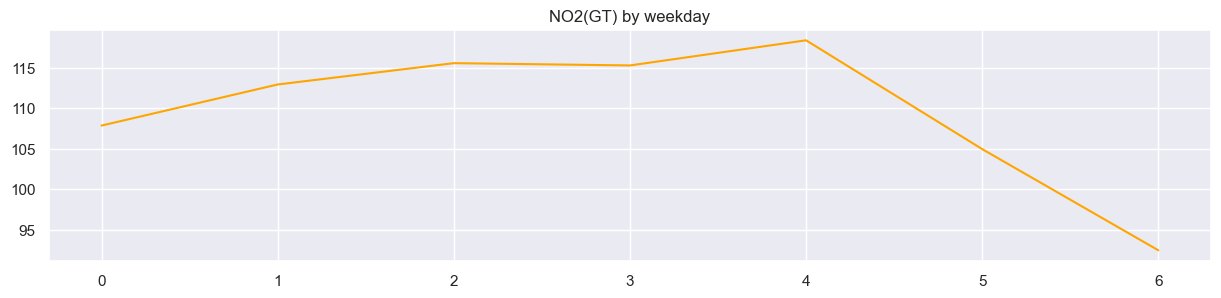

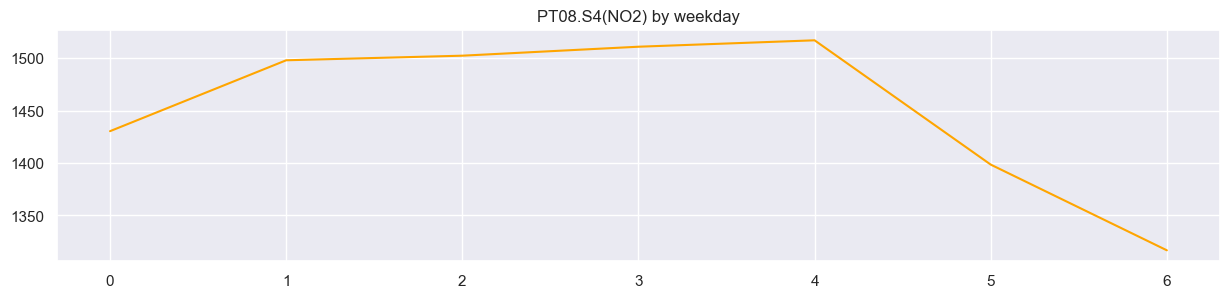

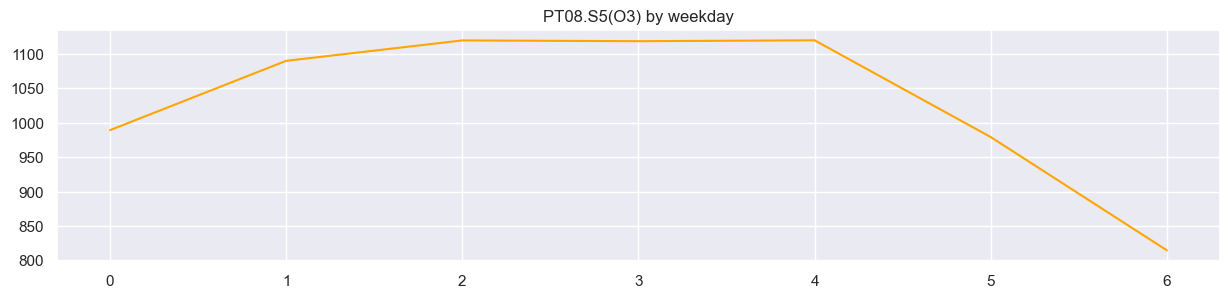

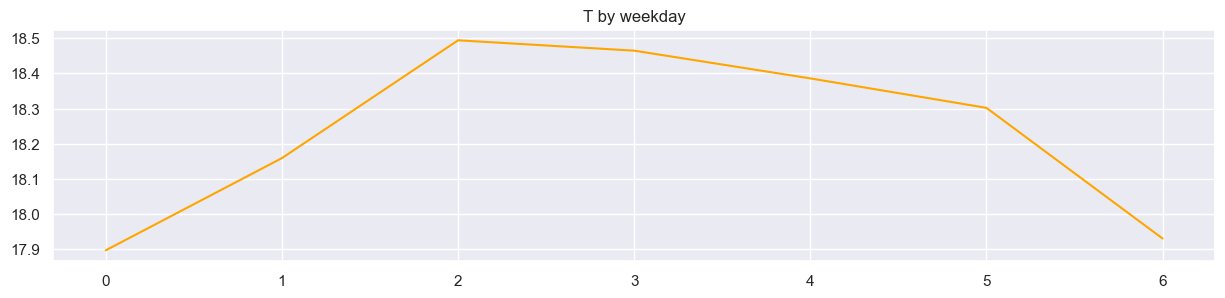

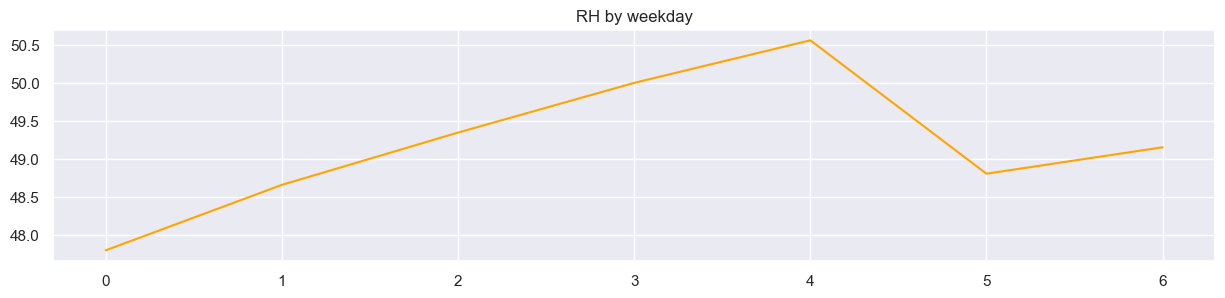

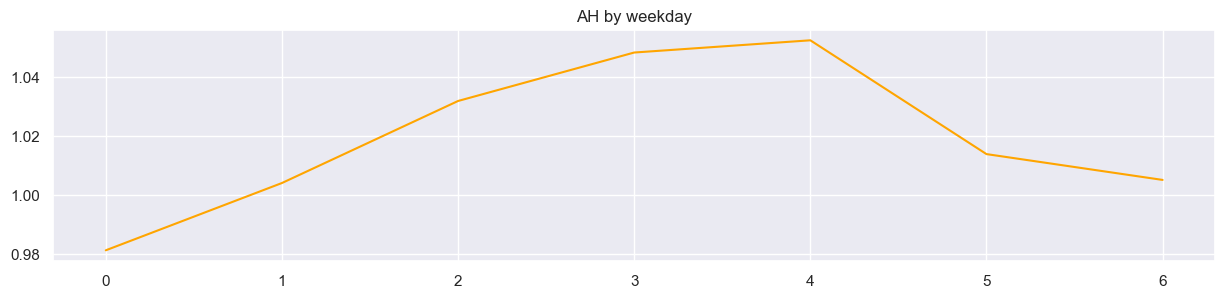

In [96]:
sns.set_theme({'figure.figsize':(15, 3)})

for feature in df:
    if feature != 'Date_Time' and feature != 'Hour' and feature != 'Day' and feature != 'weekday':
        yy = df.groupby('weekday')[feature].mean()
        plt.plot(yy, color='orange')
        plt.title(f"{feature} by weekday")
        plt.show()

In [105]:
columns_to_scale = [col for col in df.columns if col not in ['Date_Time', 'Hour', 'Day', 'weekday']]
print(columns_to_scale)

['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


# Now we standardize the data

In [106]:
# see the mean and sd one time before
df.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Date_Time,Hour,Day,weekday
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357,9357.000000,9357.000000,9357.000000
mean,2.130603,1103.059741,10.179155,942.142620,241.922197,832.758897,109.632094,1453.298814,1032.544298,18.233408,49.191386,1.019621,2004-09-21 16:00:00,11.498557,15.876884,3.009939
min,0.100000,647.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,2004-03-10 18:00:00,0.000000,1.000000,0.000000
25%,1.100000,938.000000,4.500000,736.000000,96.000000,654.000000,76.000000,1227.000000,733.000000,11.700000,35.800000,0.732300,2004-06-16 05:00:00,5.000000,8.000000,1.000000
50%,1.800000,1067.000000,8.300000,910.012987,180.000000,804.000000,104.917526,1460.000000,970.000000,17.600000,49.600000,0.989500,2004-09-21 16:00:00,11.000000,16.000000,3.000000
75%,2.900000,1239.000000,14.100000,1119.000000,326.000000,968.000000,136.314685,1668.000000,1293.000000,24.300000,62.300000,1.306700,2004-12-28 03:00:00,18.000000,23.000000,5.000000
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00,23.000000,31.000000,6.000000
std,1.431736,218.196346,7.503812,267.866611,204.315075,255.709833,46.462311,343.206131,404.447613,8.781791,17.194506,0.402203,NaN,6.923182,8.808653,2.000323


In [111]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[columns_to_scale])

In [123]:
scaled_df=pd.DataFrame(scaled_data, columns=columns_to_scale)
scaled_df.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03
mean,-2.429985e-17,-2.399610e-16,-6.074962e-17,-8.504947e-17,6.074962e-18,-6.682458e-17,-4.859970e-17,-1.214992e-16,-9.112443e-18,-4.859970e-16,-1.063118e-16,4.859970e-17
std,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00
min,-1.418356e+00,-2.090246e+00,-1.343276e+00,-2.087504e+00,-1.174338e+00,-1.997523e+00,-2.316670e+00,-2.629169e+00,-2.006657e+00,-2.292754e+00,-2.325948e+00,-2.075981e+00
25%,-7.198658e-01,-7.565139e-01,-7.568764e-01,-7.696130e-01,-7.142400e-01,-6.991067e-01,-7.238962e-01,-6.594023e-01,-7.406653e-01,-7.440119e-01,-7.788594e-01,-7.144059e-01
50%,-2.309227e-01,-1.652716e-01,-2.504401e-01,-1.199528e-01,-3.030883e-01,-1.124729e-01,-1.014762e-01,1.952630e-02,-1.546495e-01,-7.213130e-02,2.376548e-02,-7.489351e-02
75%,5.374163e-01,6.230513e-01,5.225418e-01,6.602795e-01,4.115325e-01,5.289133e-01,5.743153e-01,6.256085e-01,6.440132e-01,6.908518e-01,7.624130e-01,7.138053e-01
max,6.823827e+00,4.294253e+00,7.132869e+00,4.748353e+00,6.055079e+00,7.236092e+00,4.958432e+00,3.851248e+00,3.685361e+00,3.002577e+00,2.297869e+00,3.012022e+00


### Must join back the 4 cols back with these

In [121]:
time_columns = df[['Date_Time', 'Hour', 'Day', 'weekday']]

final_df = pd.concat([scaled_df, time_columns], axis=1)

In [122]:
final_df.head()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Date_Time,Hour,Day,weekday
0,0.327869,1.177627,0.229342,0.387741,-0.371614,0.873072,0.072491,0.695541,0.582197,-0.527644,-0.016947,-0.651002,2004-03-10 18:00:00,18,10,2
1,-0.091225,0.865965,-0.103840,0.048002,-0.679977,1.334557,-0.379513,0.307998,-0.149704,-0.561807,-0.086741,-0.731314,2004-03-10 19:00:00,19,10,2
2,0.048473,1.370125,-0.157149,-0.011733,-0.542927,1.201587,0.094015,0.296343,0.102505,-0.721236,0.279675,-0.669899,2004-03-10 20:00:00,20,10,2
3,0.048473,1.250960,-0.130495,0.021868,-0.342246,1.013864,0.266206,0.380845,0.421476,-0.823727,0.628642,-0.579144,2004-03-10 21:00:00,21,10,2
4,-0.370621,0.774299,-0.490331,-0.396273,-0.542927,1.455795,0.137063,0.106942,0.191520,-0.800951,0.605378,-0.573922,2004-03-10 22:00:00,22,10,2


# Plotting again to make sure everything has worked fine

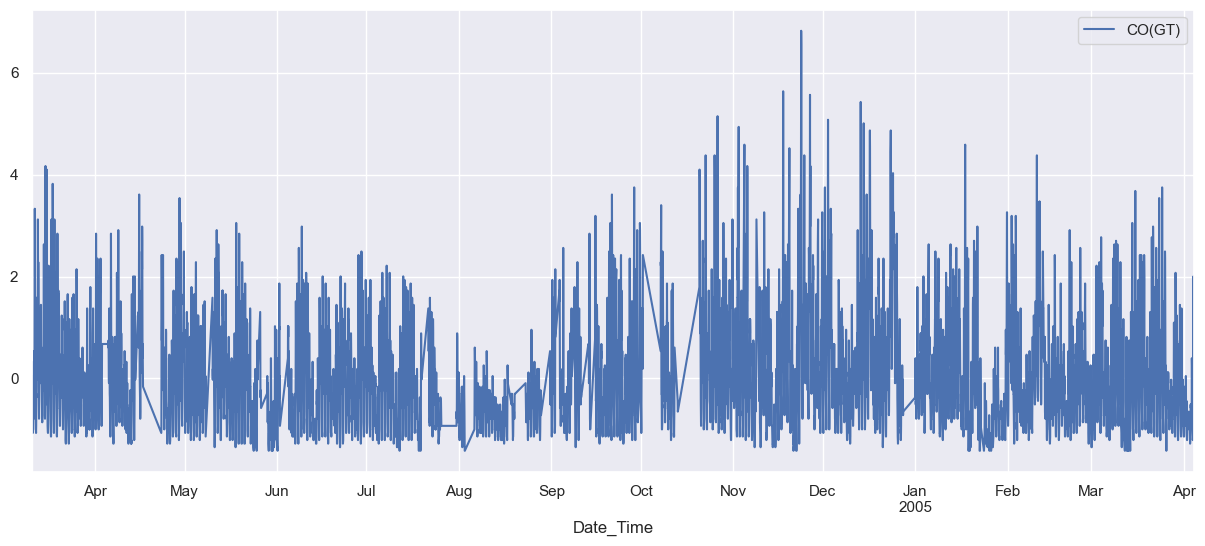

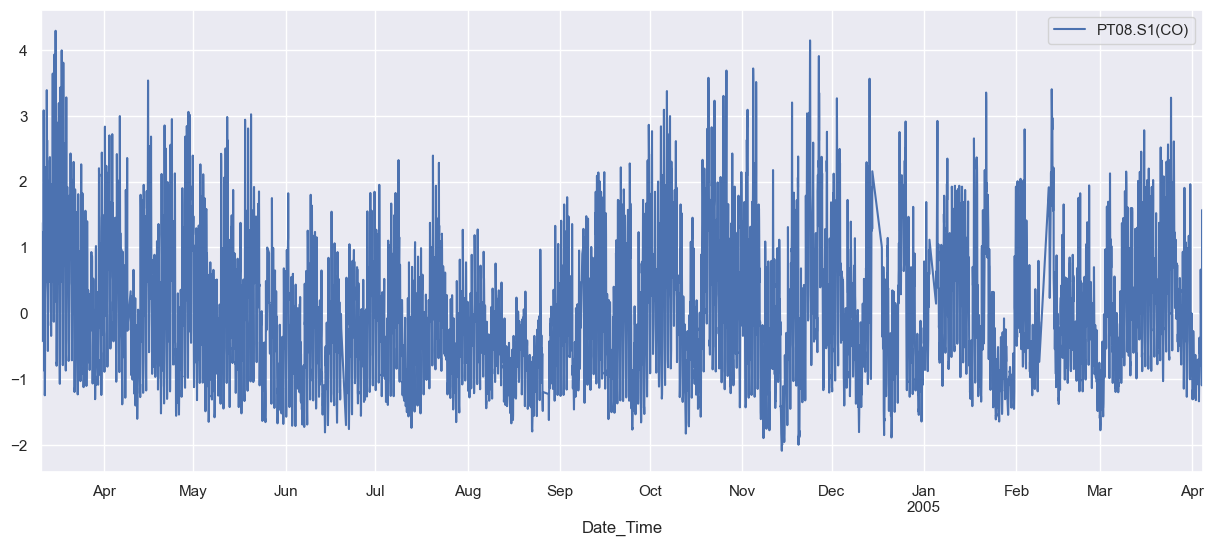

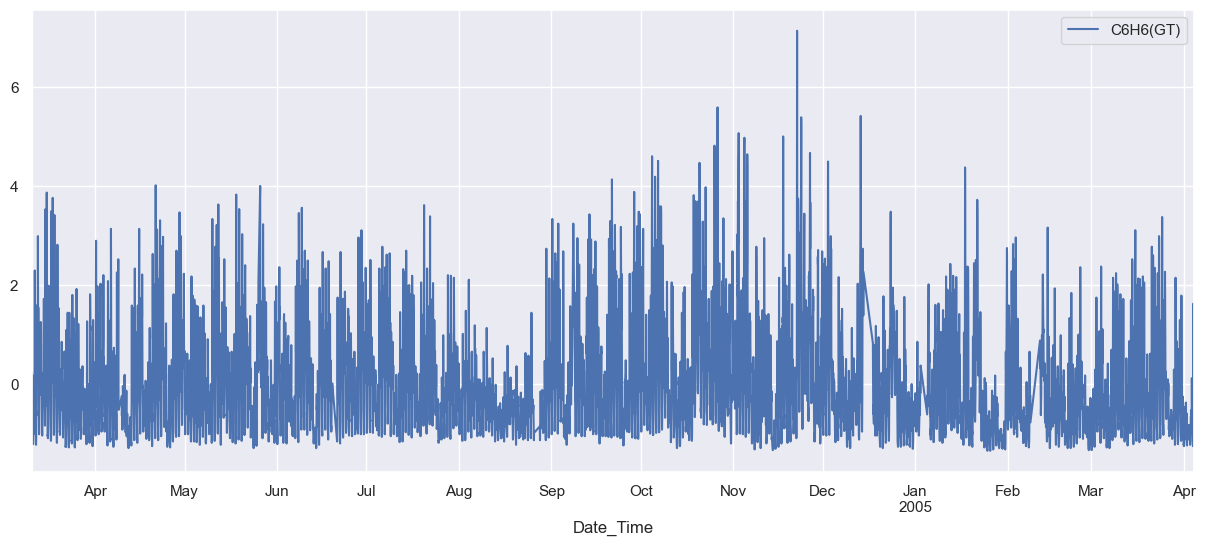

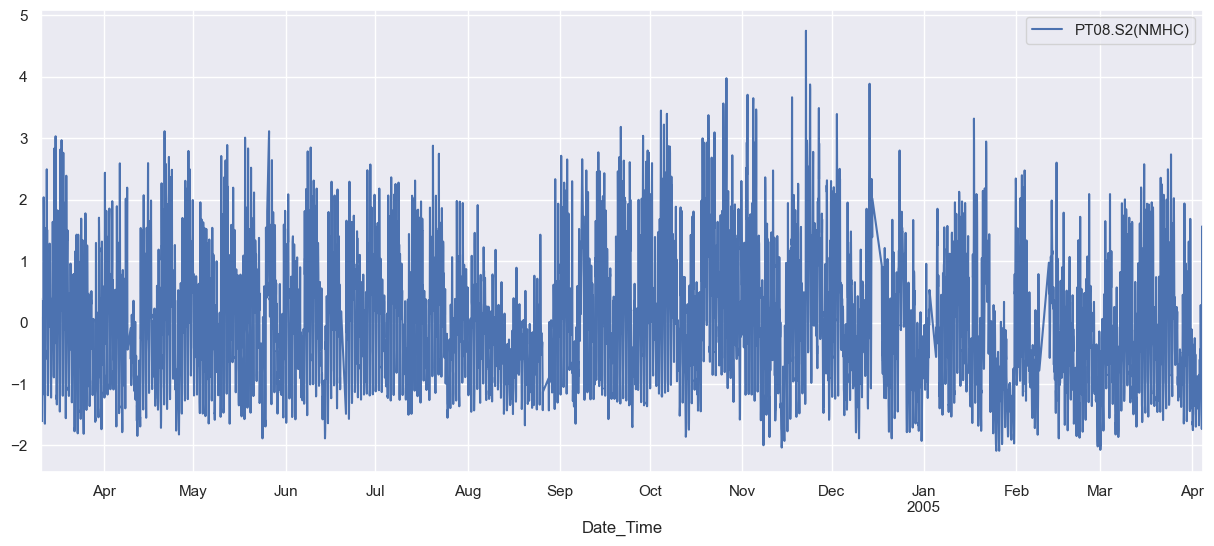

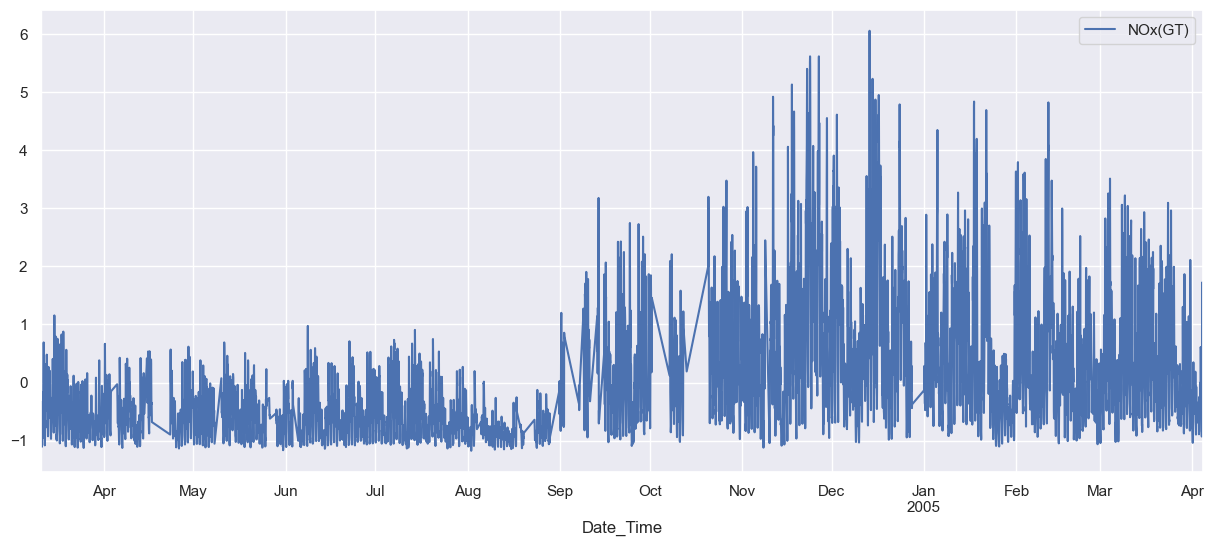

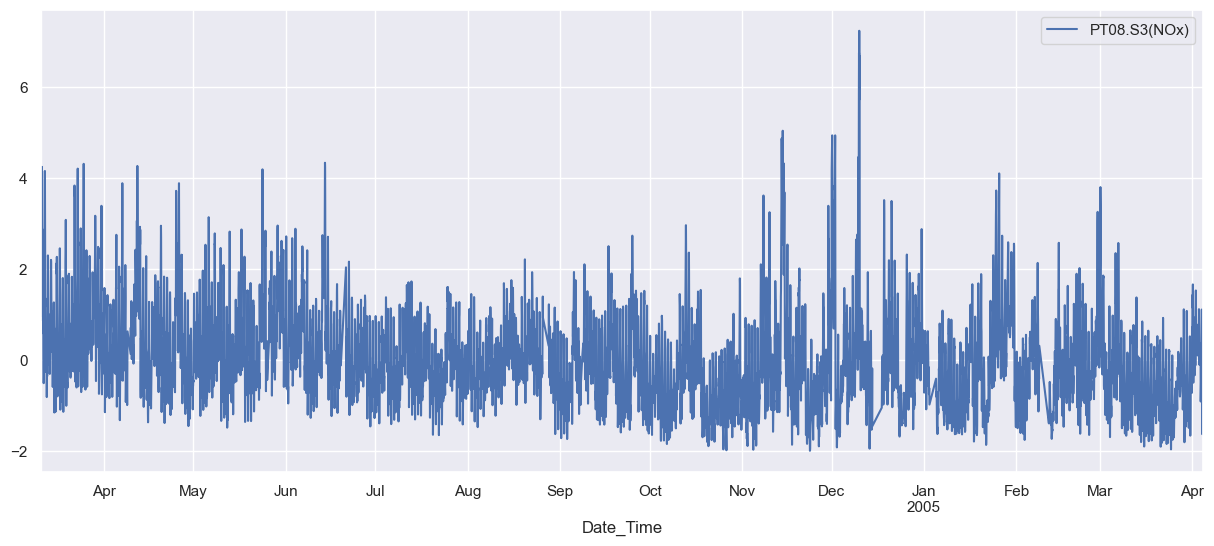

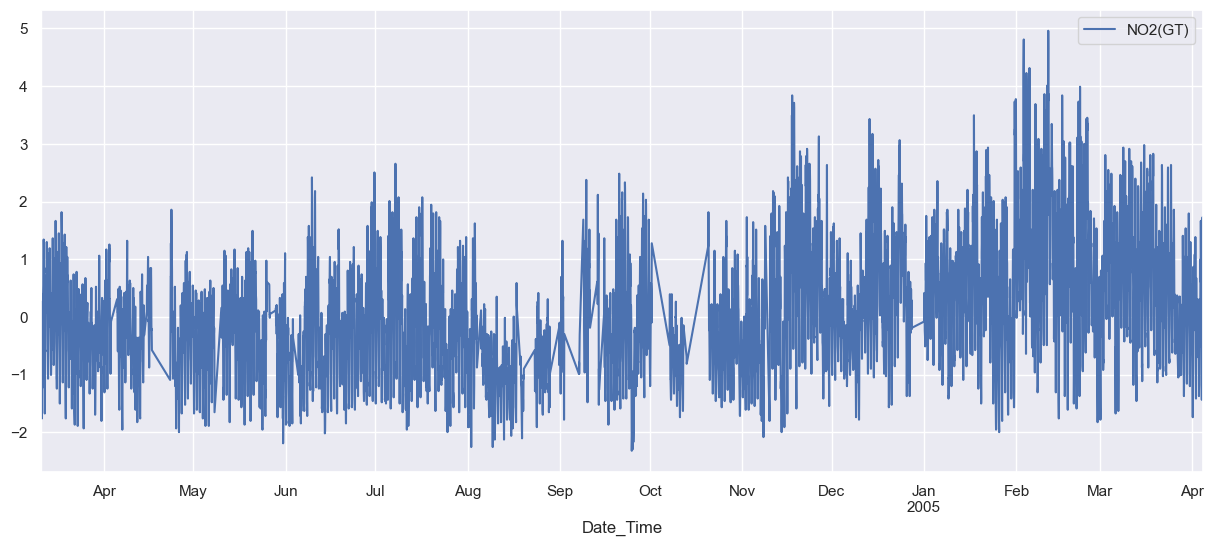

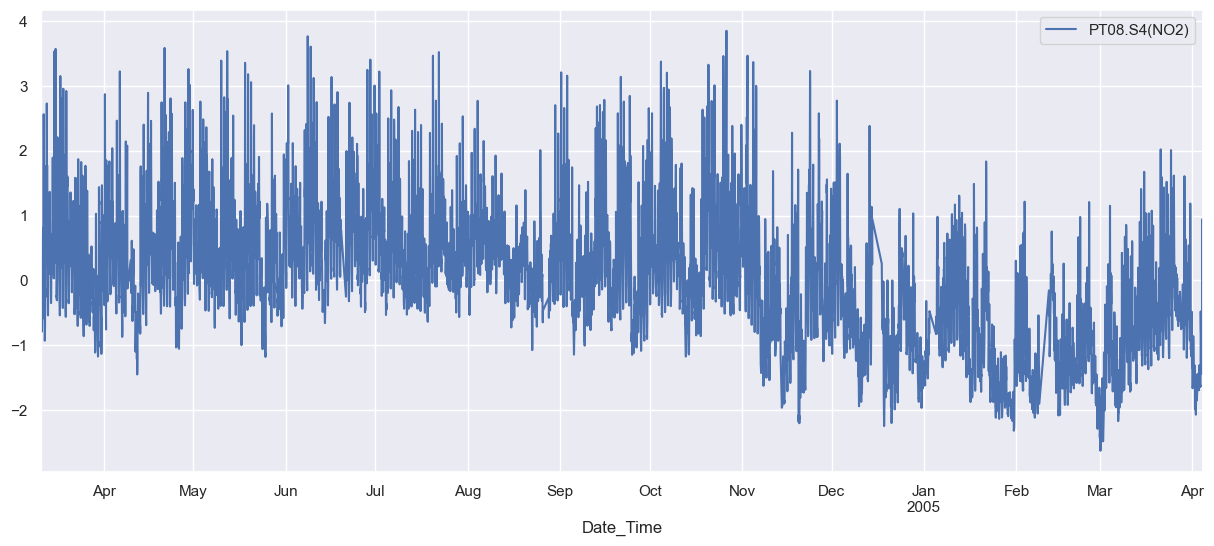

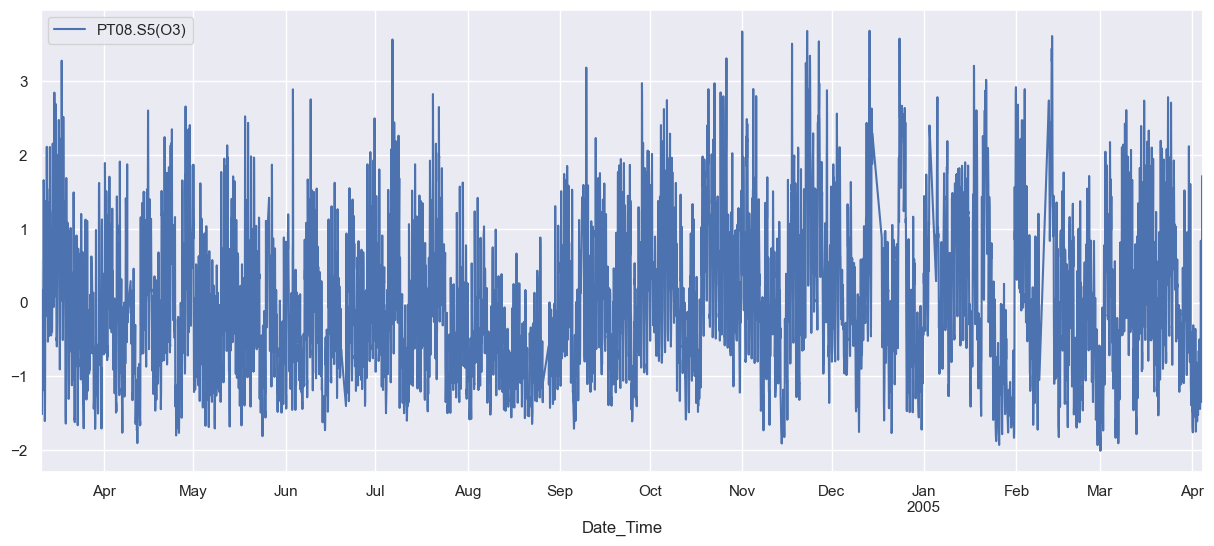

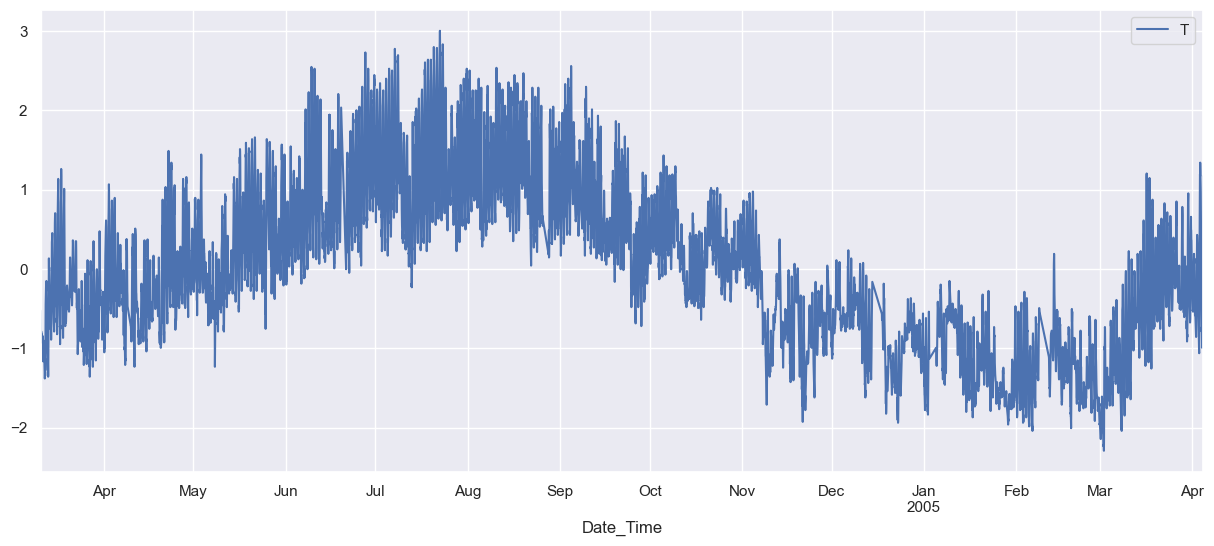

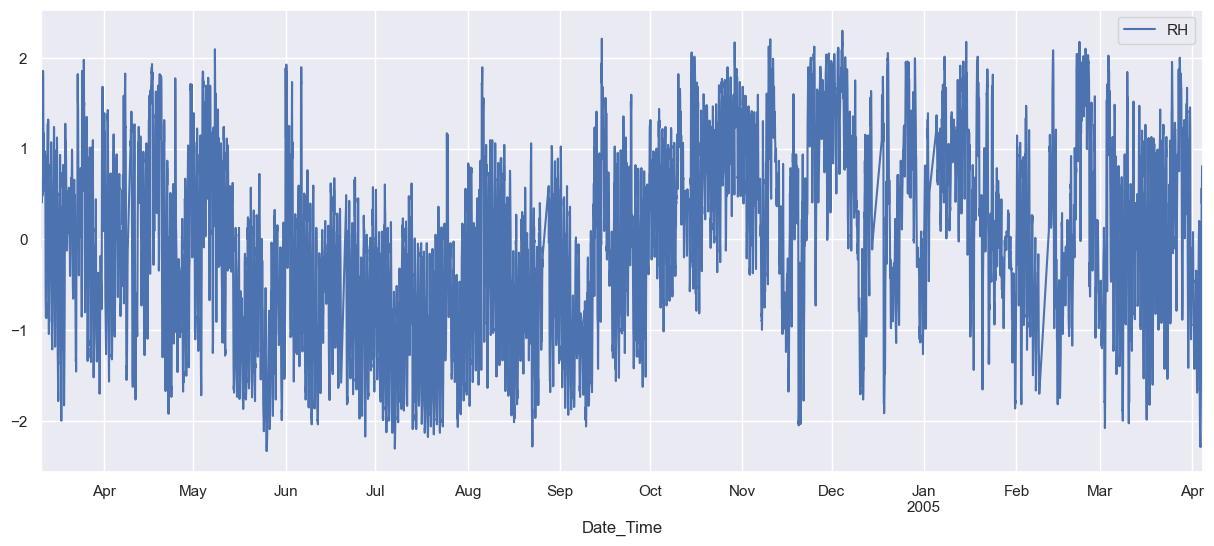

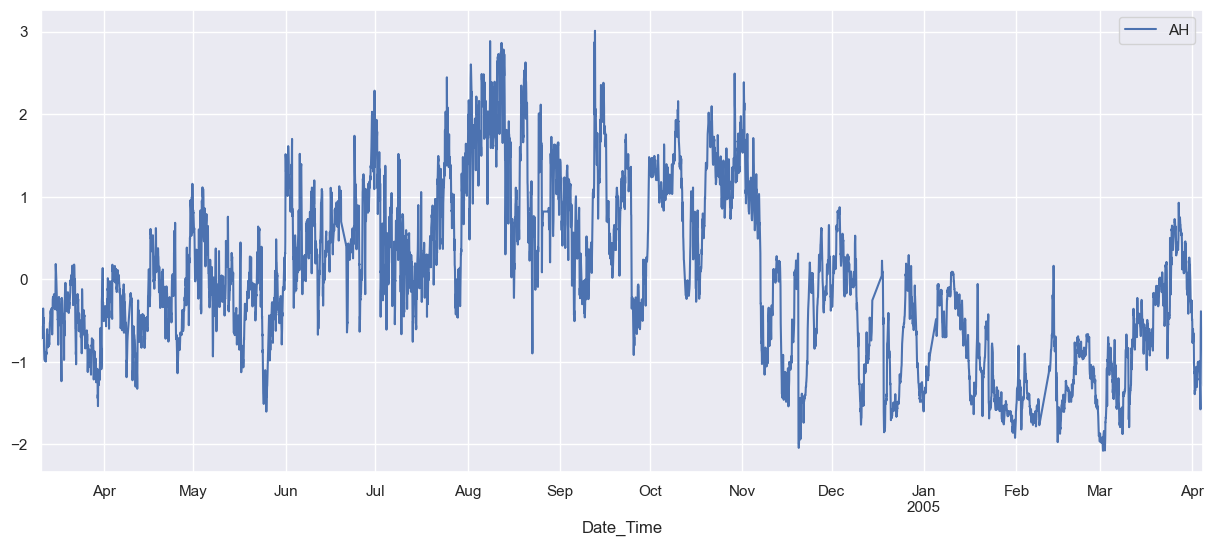

In [129]:
sns.set_theme({'figure.figsize':(15, 6)})

for feature in final_df:
    if feature != 'Date_Time' and feature != 'Hour' and feature != 'Day' and feature != 'weekday':
        final_df.plot(x='Date_Time', y=feature)
        plt.show()

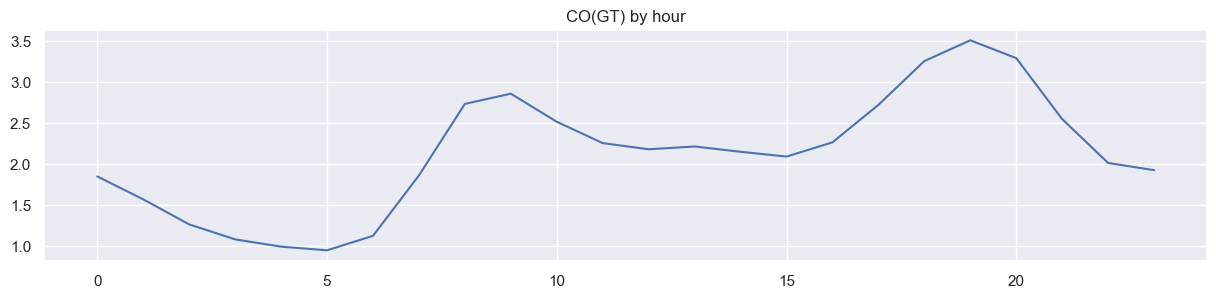

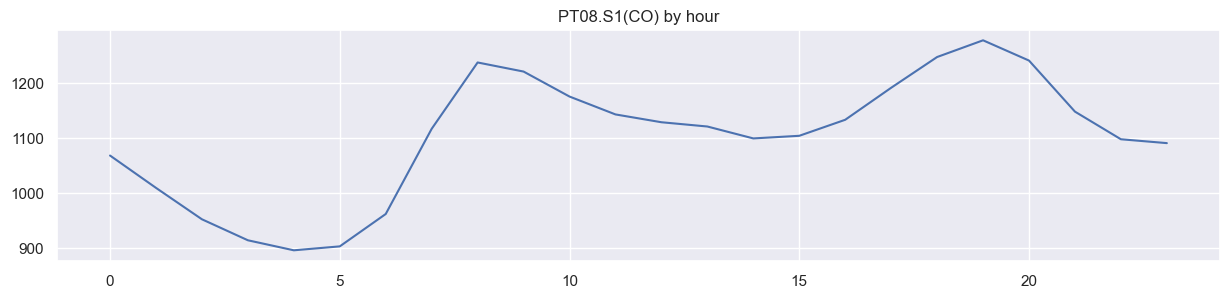

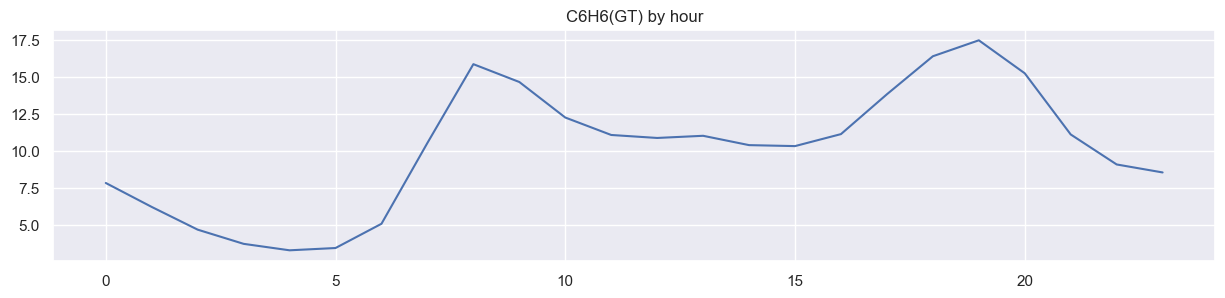

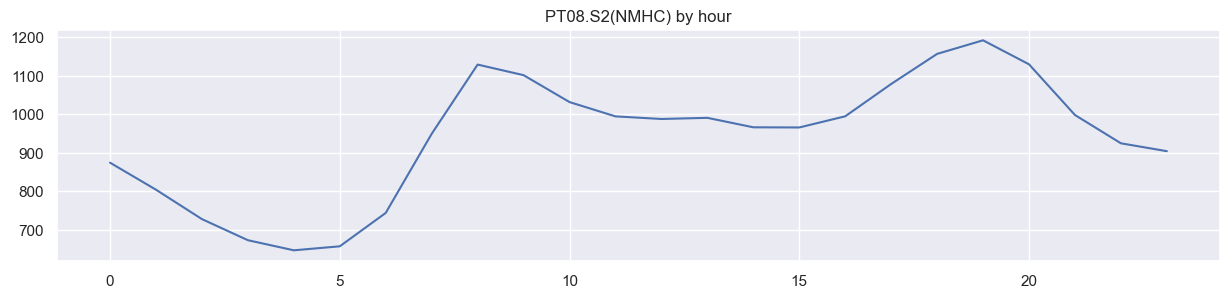

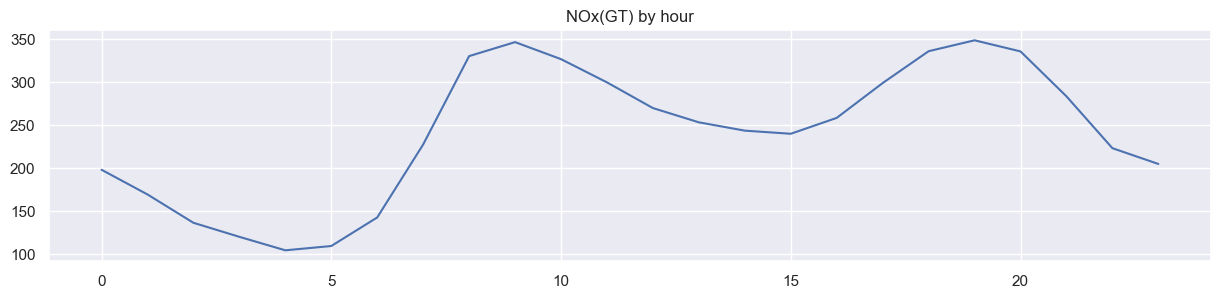

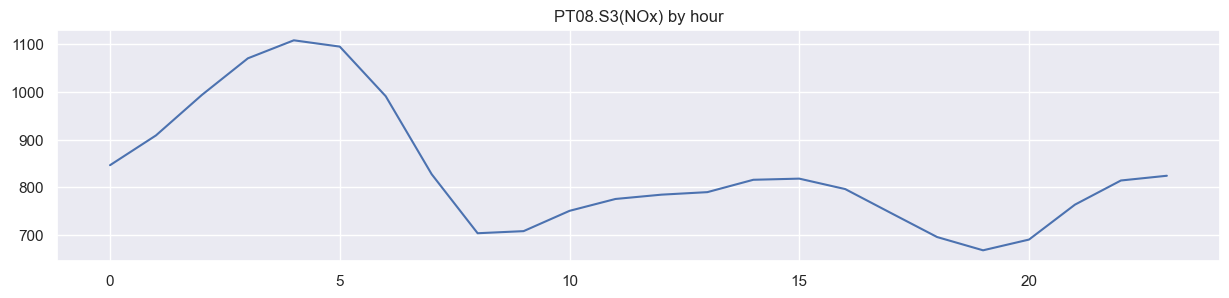

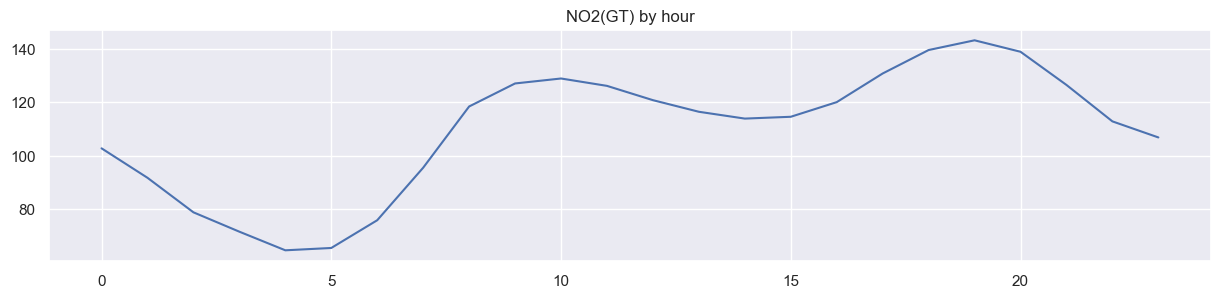

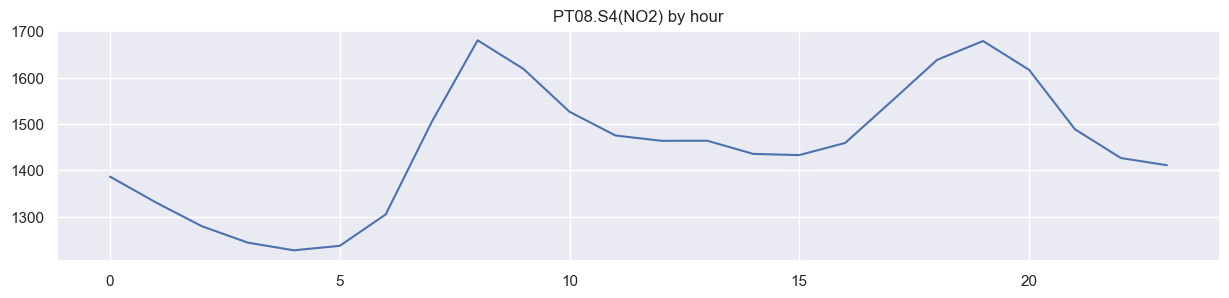

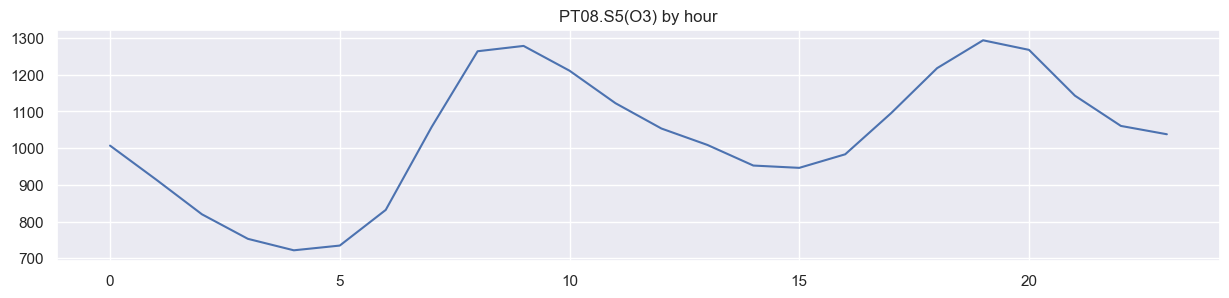

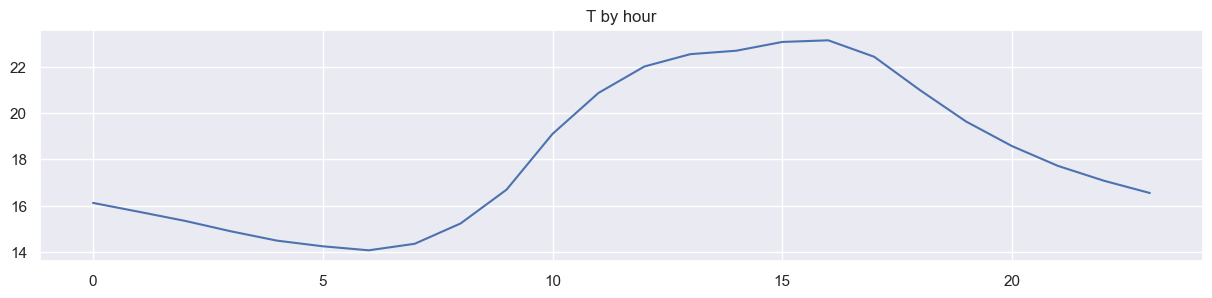

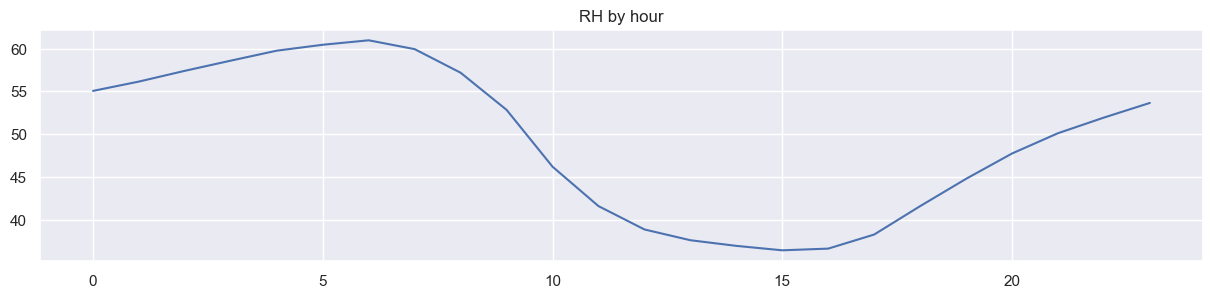

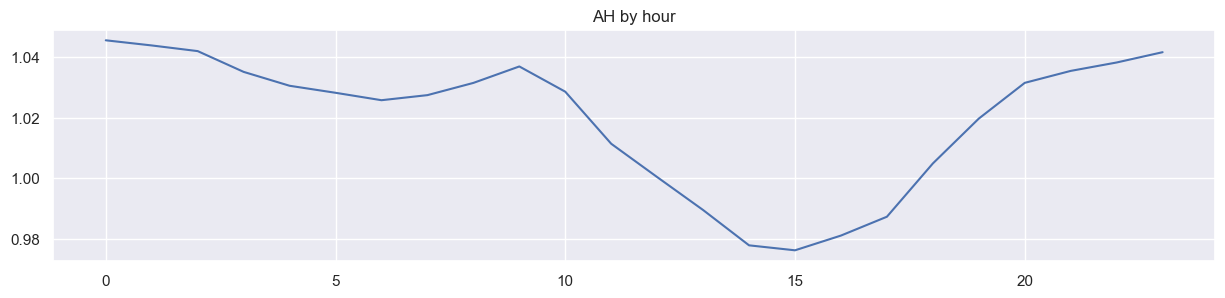

In [125]:
sns.set_theme({'figure.figsize':(15, 3)})

for feature in final_df:
    if feature != 'Date_Time' and feature != 'Hour' and feature != 'Day' and feature != 'weekday':
        yy = final_df[feature].groupby(df['Hour']).mean()
        plt.plot(yy)
        plt.title(f"{feature} by hour")
        plt.show()

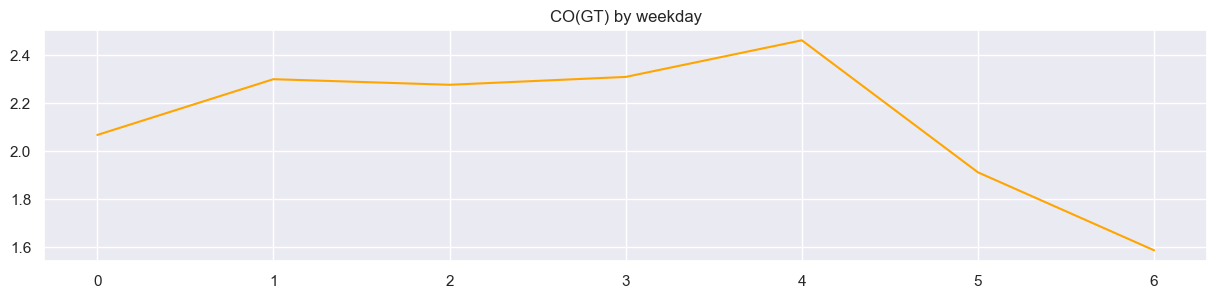

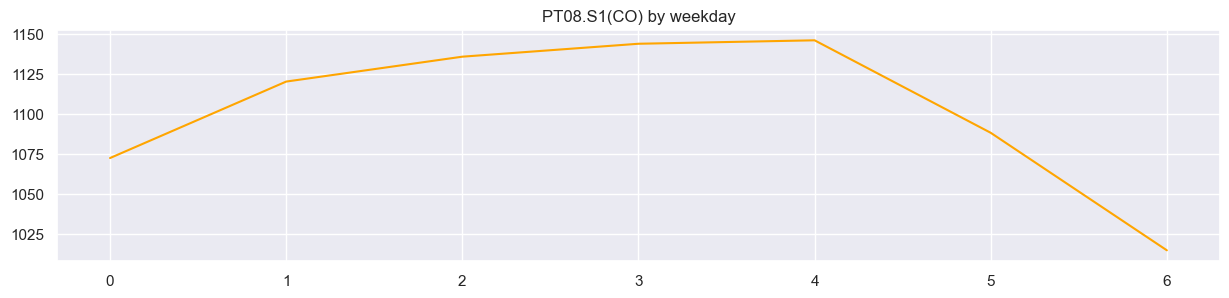

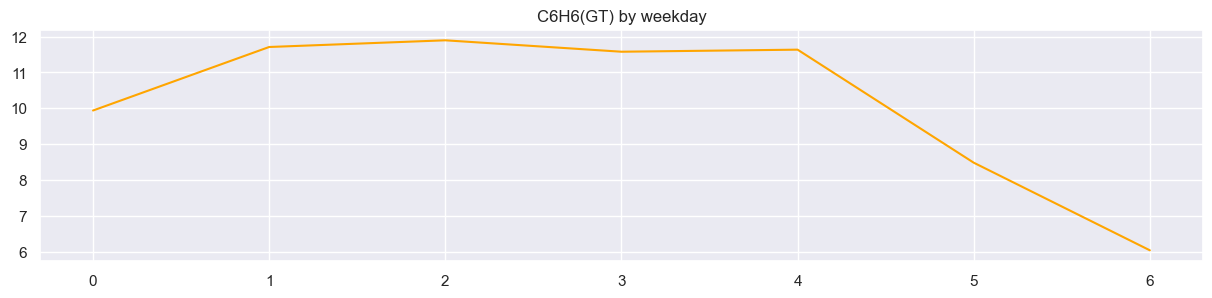

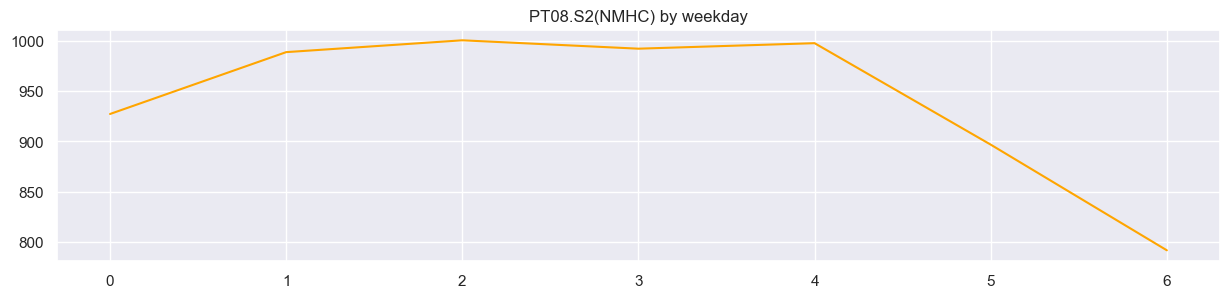

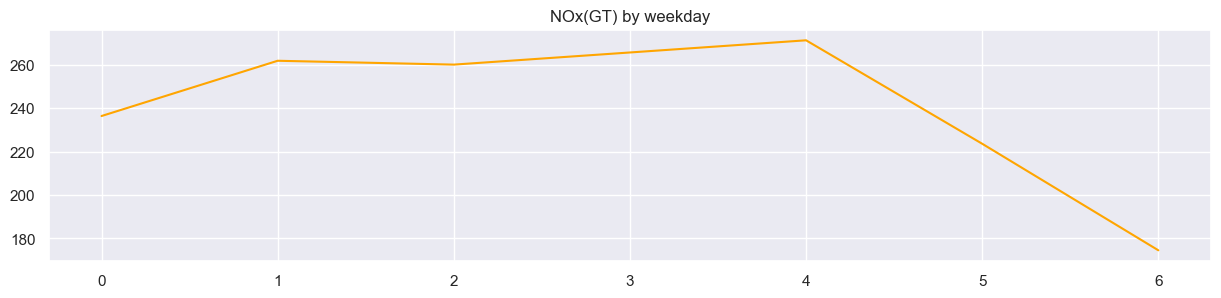

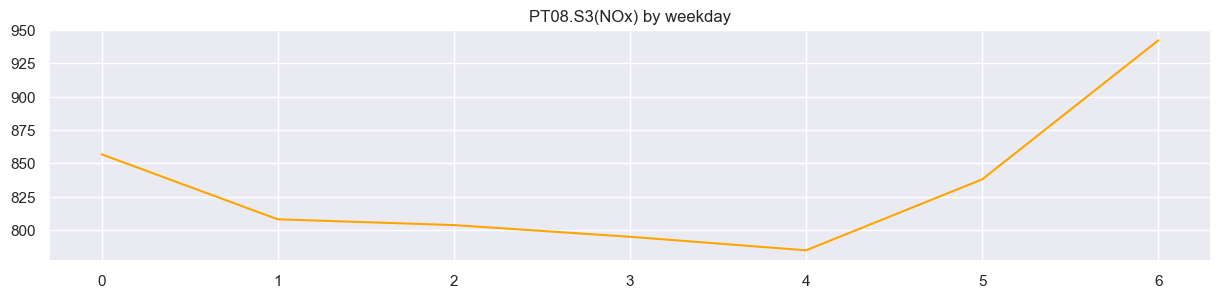

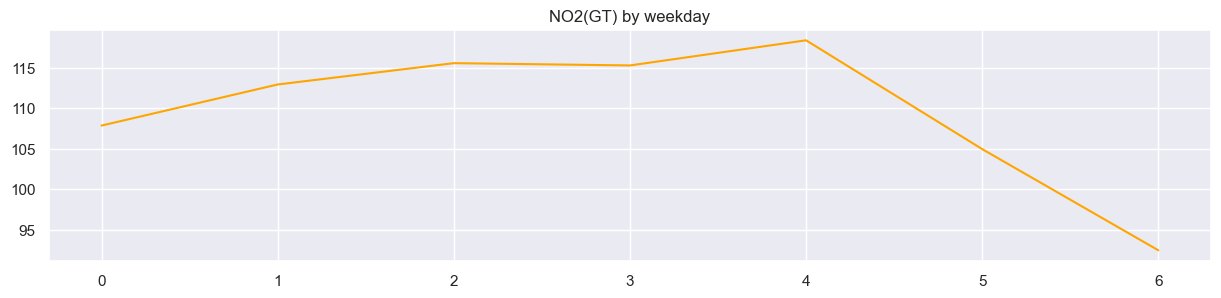

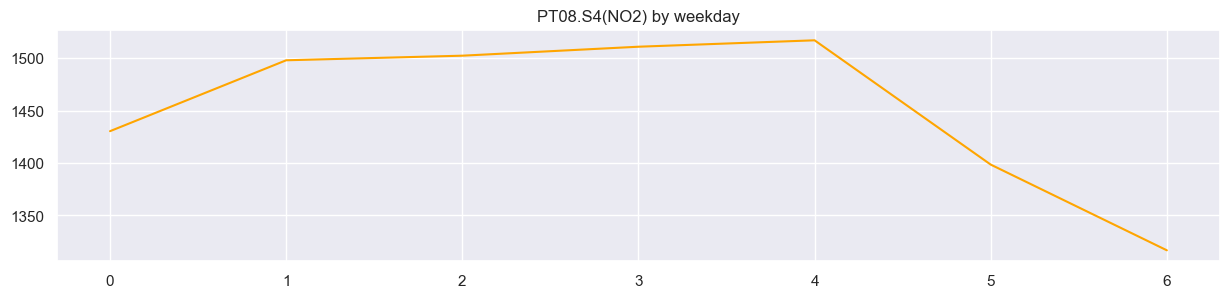

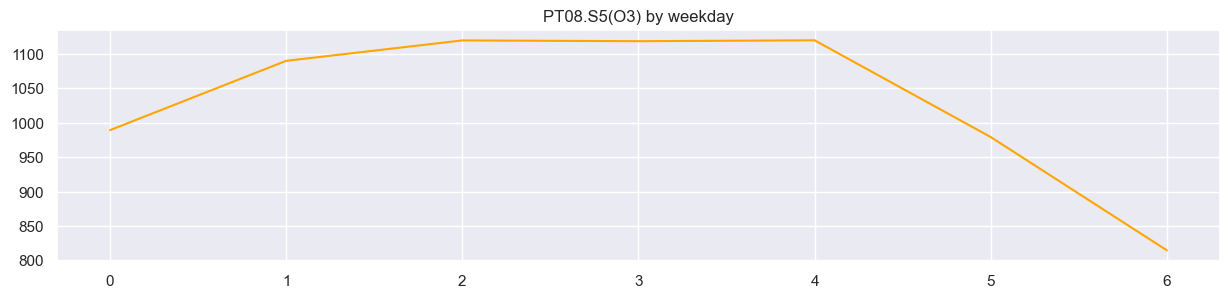

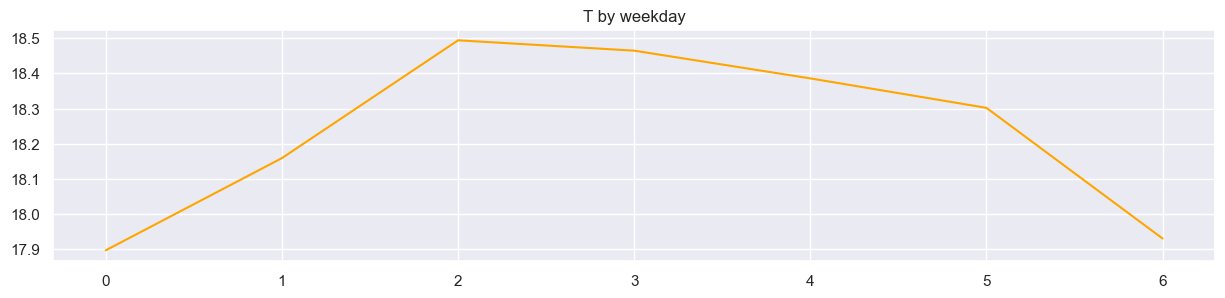

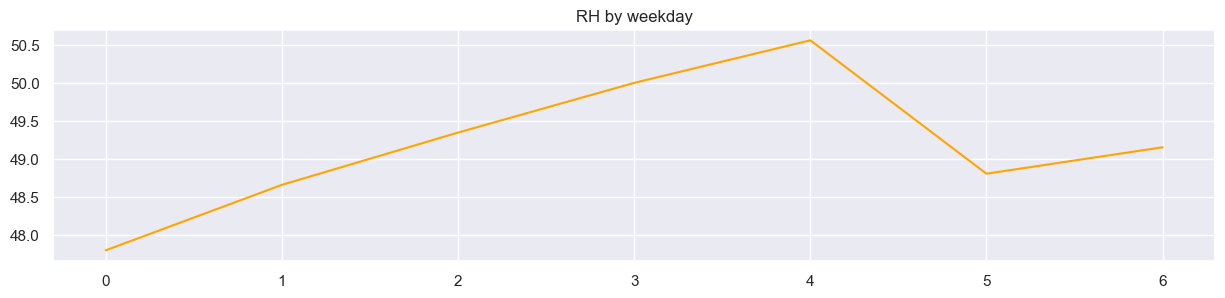

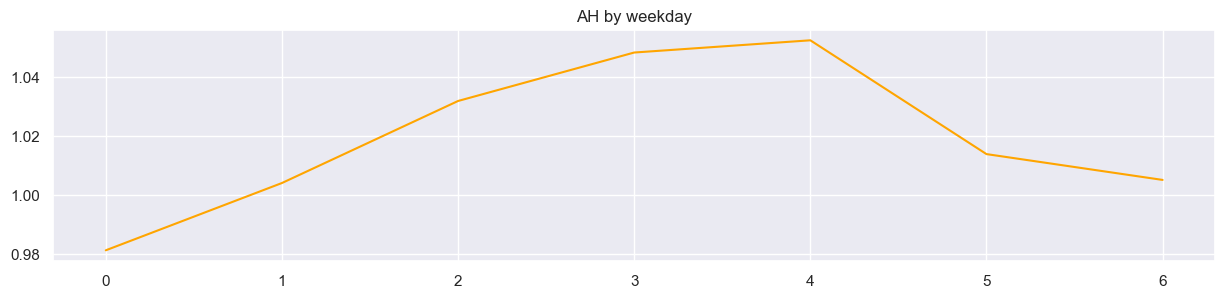

In [127]:
sns.set_theme({'figure.figsize':(15, 3)})

for feature in final_df:
    if feature != 'Date_Time' and feature != 'Hour' and feature != 'Day' and feature != 'weekday':
        yy = final_df.groupby('weekday')[feature].mean()
        plt.plot(yy, color='orange')
        plt.title(f"{feature} by weekday")
        plt.show()

# We now export this dataset into a new csv file

In [130]:
final_df.to_csv('Data/processed_AirQualityUCI.csv', index=False)

In [142]:
tempdf = df
tempdf.to_csv('Data/unscaled_processed_airdata.csv', index=False)

In [141]:
df.head(10)

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Date_Time,Hour,Day,weekday
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00,18,10,2
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00,19,10,2
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00,20,10,2
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00,21,10,2
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00,22,10,2
5,1.2,1197.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848,2004-03-10 23:00:00,23,10,2
6,1.2,1185.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603,2004-03-11 00:00:00,0,11,3
7,1.0,1136.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,60.0,0.7702,2004-03-11 01:00:00,1,11,3
8,0.9,1094.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648,2004-03-11 02:00:00,2,11,3
9,0.6,1010.0,1.7,561.0,33.0,1705.0,47.0,1235.0,501.0,10.3,60.2,0.7517,2004-03-11 03:00:00,3,11,3
